# Q1 [4 marks]
## Objective

To implement **LDA** from scratch and analyze how class-specific covariance structures influence classification performance  

Part 1: The Homoscedastic Case (Same Covariance)

In this scenario, we satisfy the core assumption of LDA: all classes share the same shape and orientation in space.  

Task 1: Data Generation

Generate a dataset in R10 with 3 classes.

    Means: μ1​,μ2​,μ3​ should be distinct.

    Covariance: Use a single Σ for all classes.


In [2]:
# Implement Part 1
import numpy as np
import matplotlib.pyplot as plt

dimens=10
points_per_class=500
# I am picking some random numbers for the centers of my 3 classes
#Mean for class 1
m1=np.array([0.5, 0.2, 0.1, 0.0, 0.4, 0.1, 0.2, 0.3, 0.1, 0.5])
#Mean for class 2
m2=np.array([-0.2, 0.1, 0.4, 0.3, 0.1, -0.1, 0.0, 0.2, 0.4, -0.1])
#Mean for class 3
m3=np.array([0.1, -0.3, 0.2, 0.1, -0.1, 0.3, 0.5, 0.0, 0.1, 0.2])

# I am creating a vector of 10 dimensions so that I can multiply that vector with it's transpose 
# to create single covariance matrix which will be symmetric
temp_vect=np.random.rand(10,10)
shared_covariance=np.dot(temp_vect,temp_vect.T)

# Now I am generating points for each class having different mean
#for each class and shared covariance matrix
class0_points=np.random.multivariate_normal(m1,shared_covariance,points_per_class)
class1_points=np.random.multivariate_normal(m2,shared_covariance,points_per_class)
class2_points=np.random.multivariate_normal(m3,shared_covariance,points_per_class)

#Combining all generated points to a single data structure
#so that we can label them

all_class_points=np.concatenate([class0_points, class1_points,class2_points],axis=0)


#Now I will assign each points some class 
table_for_labelling=np.zeros(1500)
for i in range(1500):
    if i<500:
        table_for_labelling[i]=0
    elif i<1000:
        table_for_labelling[i]=1
    else:
        table_for_labelling[i]=2
        





Task 2: Implementation & Visualization

    Implement the SW​ and SB​ calculations.

    Project the 10D data into 2D.

    Plot: Use a scatter plot to visualize the classes in the new 2D space.

Accuracy on the unseen Test Data is: 0.9566666666666667


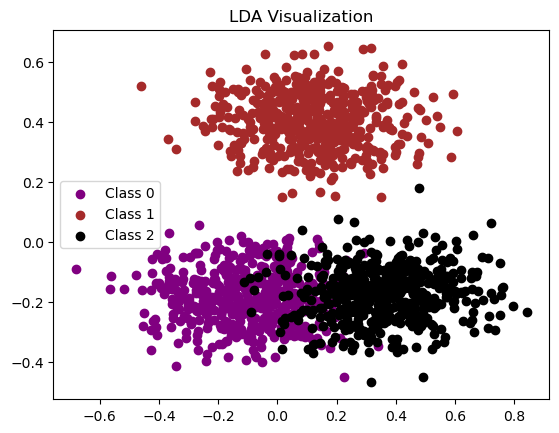

In [3]:
# Implement Task 2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
#Now I will calculate mean of each class
class0_avg=np.mean(class0_points,axis=0)
class1_avg=np.mean(class1_points,axis=0)
class2_avg=np.mean(class2_points,axis=0)
all_points_avg=np.mean(all_class_points,axis=0)

# Now I am creating an empty 10*10 matrix to calculate Sw(Within-class Scatter Matrix) 
#later on I will add values to it
within_scatter_matrix=np.zeros((10, 10))

#Adding contribution of class0 points to within scatter matrix
for row in range(500):
    diff=class0_points[row]-class0_avg
    diff=diff.reshape(10,1) # Currently it is numpy array converting it to a column matrix
    prod=np.dot(diff,diff.T)
    within_scatter_matrix=within_scatter_matrix+prod

#Adding contribution of class1 points to within scatter matrix
for row in range(500):
    diff=class1_points[row]-class1_avg
    diff=diff.reshape(10,1) # Currently it is numpy array converting it to a column matrix
    prod=np.dot(diff,diff.T)
    within_scatter_matrix=within_scatter_matrix+prod
#Adding contribution of class2 points to within scatter matrix
for row in range(500):
    diff=class2_points[row]-class2_avg
    diff=diff.reshape(10,1) # Currently it is numpy array converting it to a column matrix
    prod=np.dot(diff,diff.T)
    within_scatter_matrix=within_scatter_matrix+prod

# Now I will calculate Sb(Between-class Scatter Matrix)

# Now I am creating an empty 10*10 matrix to calculate Sb(Between-class Scatter Matrix)
#later on I will add values to it
between_scatter_matrix=np.zeros((10,10))
list_of_means=[class0_avg,class1_avg,class2_avg]
for avg_per_class in list_of_means:
    diff=avg_per_class-all_points_avg
    diff=diff.reshape(10,1) # Currently it is numpy array converting it to a column matrix
    prod=500*np.dot(diff,diff.T)
    between_scatter_matrix=between_scatter_matrix+prod

# Now I will solve Eigen Decomposition 
# Equation that I got after differentiating Eigen Decomposition is (Sw^-1*Sb)w=((w^t*Sb*w)/(w^t*Sw*w))*w
#Now it is of the form AX=lambda*X
#Now we will solve for eigen values and eigen vector of A and we take the largest two eigen values and eigen vectors corresponding to those eigen values
inv_within_scatter_matrix=np.linalg.pinv(within_scatter_matrix)
final_matrix=np.dot(inv_within_scatter_matrix,between_scatter_matrix)
my_eig_vals,my_eig_vecs=np.linalg.eig(final_matrix)

#Now I will pick two largest eigen values
best_eig_vals=np.argsort(my_eig_vals.real)
largest_two=best_eig_vals[-2:]

# Now I will create projection matrix with eigen vectors corresponding to top 2 eigen values
project_mat=my_eig_vecs[:,largest_two].real
#Now I will project points from 10D to 2D
projected_points=np.dot(all_class_points,project_mat)

#Logistic Regression on 2D Data
# Now, I want to see how well a linear classifier works on these 2D points
# I'll use a simple 80-20 split for this test
x_train_homo, x_test_homo, y_train_homo, y_test_homo = train_test_split(projected_points, table_for_labelling, test_size=0.2, random_state=42) # I use this so I get the same split every time I run it)
lda_homo_lr=LogisticRegression()
lda_homo_lr.fit(x_train_homo,y_train_homo)
test_homo_pred=lda_homo_lr.predict(x_test_homo)
#Calculating final accuracy
final_homo_accuracy=accuracy_score(y_test_homo,test_homo_pred)
print("Accuracy on the unseen Test Data is:", final_homo_accuracy)


plt.scatter(projected_points[0:500,0],projected_points[0:500,1],color='purple',label='Class 0')
plt.scatter(projected_points[500:1000,0],projected_points[500:1000,1],color='brown',label='Class 1')
plt.scatter(projected_points[1000:1500,0],projected_points[1000:1500,1],color='black',label='Class 2')
plt.legend()
plt.title("LDA Visualization")
plt.savefig("Visualization of 2D plot.png")
plt.show()









    
    






Part 2: The Heteroscedastic Case (Different Covariances)

What happens when classes have different shapes? 

Task 3: Data Generation

Generate a new 10D dataset where each class has a unique covariance matrix (Σ1​,Σ2​,Σ3​).

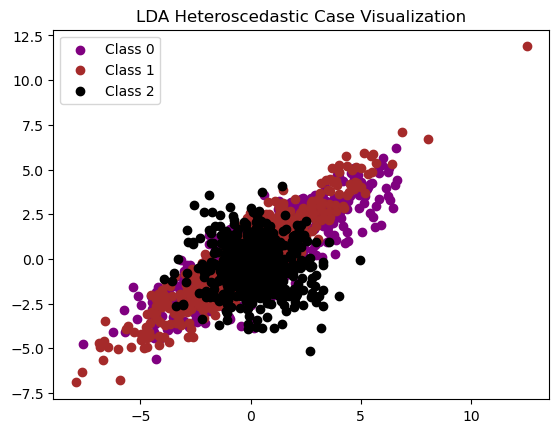

In [ ]:
# Implement Task 3
# Now I am  creating different unique convariances for each class
cov_class0=shared_covariance*1.5
cov_class1=np.random.rand(10,10)
cov_class1=np.dot(cov_class1,cov_class1.T)+2.0
cov_class2=np.eye(10)*2.0
hetero_data0=np.random.multivariate_normal(m1,cov_class0,500)
hetero_data1=np.random.multivariate_normal(m2,cov_class1,500)
hetero_data2=np.random.multivariate_normal(m3,cov_class2,500)

hetero_all_class_points=np.concatenate([hetero_data0,hetero_data1,hetero_data2])

plt.scatter(hetero_all_class_points[0:500,0],hetero_all_class_points[0:500,1],color='purple',label='Class 0')
plt.scatter(hetero_all_class_points[500:1000,0],hetero_all_class_points[500:1000,1],color='brown',label='Class 1')
plt.scatter(hetero_all_class_points[1000:1500,0],hetero_all_class_points[1000:1500,1],color='black',label='Class 2')
plt.legend()
plt.title("LDA Heteroscedastic Case Visualization")
plt.savefig("Visualization of Heteroscedastic 2D plot.png")
plt.show()






Task 4: Comparison

    LDA Pipeline: Apply your scratch LDA to this new data, project to 2D, and train a classifier.

    QDA Implementation: Use sklearn library to classify the data.

In [5]:
# Implement Task 4
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA_Library


# Now, I will split the hetero data into training and testing data
# I will use 80 % for training and 20% for testing to see how it performs
x_train, x_test, y_train, y_test=train_test_split(hetero_all_class_points,table_for_labelling,test_size=0.2, random_state=42)

hetero_train_class0=x_train[y_train==0]
hetero_train_class1=x_train[y_train==1]
hetero_train_class2=x_train[y_train==2]
# Now I am calculating mean for each class in the training set
hetero_avg_c0=np.mean(hetero_train_class0,axis=0)
hetero_avg_c1=np.mean(hetero_train_class1,axis=0)
hetero_avg_c2=np.mean(hetero_train_class2,axis=0)
hetero_avg_total=np.mean(x_train,axis=0)

#Now I am calculating Sw(Within-class scatter ) for this hetero data
# I am initialiazing a zero matrix and adding each row's contribution with a loop
hetero_within_scatter_matrix=np.zeros((10,10))

# Now I am calculating contribution of class0 to Within-Scatter Matrix
for i in range(len(hetero_train_class0)):
    h_diff=hetero_train_class0[i]-hetero_avg_c0
    h_diff=h_diff.reshape(10,1) # Currently it is numpy array converting it to a column matrix
    prod=np.dot(h_diff,h_diff.T)
    hetero_within_scatter_matrix=hetero_within_scatter_matrix+prod
    
# Now I am calculating contribution of class0 to Within-Scatter Matrix
for i in range(len(hetero_train_class1)):
    h_diff=hetero_train_class1[i]-hetero_avg_c1
    h_diff=h_diff.reshape(10,1) # Currently it is numpy array converting it to a column matrix
    prod=np.dot(h_diff,h_diff.T)
    hetero_within_scatter_matrix=hetero_within_scatter_matrix+prod
for i in range(len(hetero_train_class2)):
    h_diff=hetero_train_class2[i]-hetero_avg_c2
    h_diff=h_diff.reshape(10,1) # Currently it is numpy array converting it to a column matrix
    prod=np.dot(h_diff,h_diff.T)
    hetero_within_scatter_matrix=hetero_within_scatter_matrix+prod
# Now I will calculate hetero Sb(Between-class Scatter) for this hetero data
hetero_between_scatter_matrix=np.zeros((10,10))
hetero_means_list=[hetero_avg_c0, hetero_avg_c1, hetero_avg_c2]
hetero_counts=[len(hetero_train_class0),len(hetero_train_class1),len(hetero_train_class2)]

for j in range(3):
    h_diff=hetero_means_list[j]-hetero_avg_total
    h_diff=h_diff.reshape(10,1)
    prod=np.dot(h_diff,h_diff.T)
    hetero_between_scatter_matrix=hetero_between_scatter_matrix+prod
    
#Now I will solve Eigen Decomposition 
#Equation that I got after differentiating Eigen Decomposition is (Sw^-1*Sb)w=((w^t*Sb*w)/(w^t*Sw*w))*w
#Now it is of the form A*X=lambda*X
#Now we will solve for eigen values and eigen vector of A and we take the largest two eigen values and eigen vectors corresponding to those eigen values
inv_htr_within_scatter_matrix=np.linalg.pinv(hetero_within_scatter_matrix)
hetero_final_matrix=np.dot(inv_htr_within_scatter_matrix,hetero_between_scatter_matrix)
hetero_eig_vals,hetero_eig_vecs=np.linalg.eig(hetero_final_matrix)

#Now I will pick two largest eigen values
hetero_best_eig_vals=np.argsort(hetero_eig_vals.real)
hetero_largest_two=hetero_best_eig_vals[-2:]
# Now I will create projection matrix with eigen vectors corresponding to top 2 eigen values

hetero_project_mat=hetero_eig_vecs[:,hetero_largest_two].real
# Now I will project points from 10D to 2D
hetero_x_train_projected_points=np.dot(x_train,hetero_project_mat)
hetero_x_test_projected_points=np.dot(x_test,hetero_project_mat)

#Now I am training Logistic Regression on x_train_projected_points
# Since it is already projected to 2D, I'll use Logistic Regression to get accuracy
lda_hetero_lr=LogisticRegression()
lda_hetero_lr.fit(hetero_x_train_projected_points,y_train)
lda_hetero_preds=lda_hetero_lr.predict(hetero_x_test_projected_points)
lda_hetero_accuracy=accuracy_score(y_test,lda_hetero_preds)
# Now I will implement Quadratic Discriminant Analysis
# As QDA will be trained on original 10D data
qda_org_model=QDA_Library()
qda_org_model.fit(x_train,y_train)
qda_org_pred=qda_org_model.predict(x_test)
qda_accuracy=accuracy_score(y_test,qda_org_pred)

print("Accuracy for LDA (Projected on 2D): ", lda_hetero_accuracy)
print("Accuracy for QDA (on original 10D)", qda_accuracy)







    
    
    


    
    







Accuracy for LDA (Projected on 2D):  0.5433333333333333
Accuracy for QDA (on original 10D) 0.99


Discussion & Analysis

After running your experiments, please provide a brief write-up addressing the following:

    Performance Gap: Compare the accuracy of LDA vs. QDA in Part 2.

    Compare the projections in Part 2 between LDA and QDA. Explain the reasoning behind it.
  

# Q2 [4]
## Goal: 
implement K-Means and Gaussian Mixture Model (GMM / EM) from scratch, apply them to the provided image, 
pick an optimal number of clustersk (and state/justify the criterion you used), reconstruct the image using the cluster assignments, and compare the results for multiple initialization methods.


You may use any library functions to compute PSNR and SSIM, as well as for reading and plotting images. The use of NumPy is also permitted.


Task 1. Implement K-Means and GMM from scratch

In [ ]:
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as check_psnr
from skimage.metrics import structural_similarity as check_ssim



# Now I am implementing K_Means from scratch
def K_Means_from_scratch(data,k,total_rounds):
#K_Means_from_scratch from scratch takes data, number of clusters, and max number of iterations that it will do to from clusters
# Now I am picking K random pixels to start as the "middle" colors
    
    start_points=np.random.choice(len(data),k,replace=False)
    centers=data[start_points]
    if total_rounds == 500:
        print(f"K-Means initial colors for intializations for k={k}:")
        print(centers)
    actual_rounds_taken=0
    for round_num in range(total_rounds):
        actual_rounds_taken = round_num + 1
        
#Now I am creating a list to keep track of which center each pixel belongs to 
        assignments=[]
        distances = np.sqrt(np.sum((data[:, np.newaxis] - centers)**2, axis=2))
        assignments = np.argmin(distances, axis=1)
       
        # No I am moving centers to the average of their pixels
        new_centers=np.zeros((k,3))
        for c in range(k):
            # Now I Find all pixels belonging to this center
            group=data[assignments==c]
            if len(group)>0:
                new_centers[c,0]=np.mean(group[:,0])
                new_centers[c,1]=np.mean(group[:,1])
                new_centers[c,2]=np.mean(group[:,2])

            else:
                new_centers[c]=data[np.random.randint(0,len(data))]
        # Now I doing covergence check
       
        max_change = 0
        for i in range(k):
            # Calculate how much this specific center moved
            shift = np.sqrt(np.sum((centers[i] - new_centers[i])**2))
            if shift > max_change:
                max_change = shift
        # I am checking if the change between old centers and new centers is very tiny.
        # I am using 0.00001 (1e-5) as my threshold.
        if max_change < 0.00001:
            print(f"K-Means Converged at round {actual_rounds_taken}")
            break
        centers=new_centers
    
    
    # Vectorized total error calculation
    total_error = np.sum((data - centers[assignments])**2)
    return centers,assignments,total_error,actual_rounds_taken

def GMM_from_scratch(pixels,k_blobs,total_rounds):
    num_pixels=pixels.shape[0]
    # Now I am just picking k random pixels
    blob_centers=pixels[np.random.choice(num_pixels,k_blobs,replace=False)]
    if total_rounds == 500:
        print(f"\n GMM Initialization of  Blob Centers for k={k_blobs}:")
        print(blob_centers)
    # Starting spreads: Giving each blob a simple identity matrix spread
    blob_shapes=[]
    for _ in range(k_blobs):
        blob_shapes.append(np.eye(3)*0.1)
    blob_shapes=np.array(blob_shapes)
    
    #Starting weights: Every blob starts with equal importance
    blob_weights=np.array([1.0/k_blobs]*k_blobs)
    actual_rounds_taken = 0
    for round_num in range(total_rounds):
        actual_rounds_taken = round_num +1
        old_blob_centers = blob_centers.copy()
        # E-Step: Now I am calculating how much each pixel belongs to each blob
        membership_probs=np.zeros((num_pixels,k_blobs))
        
        for b in range(k_blobs):
            center=blob_centers[b]
            shape=blob_shapes[b]
            weight=blob_weights[b]
            
            #Gaussian Probablity Logic
            inv_shape=np.linalg.inv(shape+ 1e-6*np.eye(3)) 
            det_shape=np.linalg.det(shape+ 1e-6*np.eye(3))
            
            diff = pixels - center
            # Now I will do matrix multiplication for the exponent part
            exponent = -0.5 * np.sum(np.dot(diff, inv_shape) * diff, axis=1)
            
            norm_const = 1.0 / np.sqrt(((2 * np.pi)**3) * det_shape)
            membership_probs[:, b] = weight * norm_const * np.exp(exponent)
            
        # Now I am normalizing the probablities so they add to 1 for each pixel
        row_sums = np.sum(membership_probs, axis=1, keepdims=True)
        
        membership_probs = np.divide(membership_probs, row_sums, where=row_sums > 0)
       
        
        
        for b in range(k_blobs):
            # Sum of probabilities for this blob across all pixels
            total_membership = np.sum(membership_probs[:, b])
            
            # Vectorized center update: weighted average of pixels
            # (num_pixels, 1) * (num_pixels, 3) summed over axis 0
            new_center = np.sum(membership_probs[:, b, np.newaxis] * pixels, axis=0)
            blob_centers[b] = new_center / (total_membership + 1e-15)
            
            # Vectorized shape (covariance) update
            diff = pixels - blob_centers[b]
            # (membership * diff^T) dot diff
            blob_shapes[b] = np.dot((membership_probs[:, b, np.newaxis] * diff).T, diff) / (total_membership + 1e-15)
            
            # Now I am updating weights
            blob_weights[b] = total_membership / num_pixels
       
        
        #Now I am doing convergence check for GMM Algorithm
        max_shift = 0
        for b in range(k_blobs):
            #Now I am calculating shift for each center
            center_shift = np.sqrt(np.sum((blob_centers[b] - old_blob_centers[b])**2))
            if center_shift > max_shift:
                max_shift = center_shift
        
        # If the largest shift is less than 0.00001, we stop early
        if max_shift < 0.00001:
            print(f"GMM Converged at round {actual_rounds_taken}")
            break
            
            
    
    
    # Final Step: Picking the best blob for all pixels at once
    final_tags = np.argmax(membership_probs, axis=1)
    
    # Now I am calculating the total error for the whole image at once
    reconstructed_pixels = blob_centers[final_tags]
    total_error = np.sum((pixels - reconstructed_pixels)**2)
        
    return blob_centers, np.array(final_tags), total_error,actual_rounds_taken

Task 2. Fit K-Means and GMM to the given image and determine the optimal number of clusters (k). Clearly specify the criterion used to select (k) (e.g., elbow method, silhouette score, or ..). Justify the selected value. Using this optimal (k), reconstruct the image with both K-Means and GMM and plot the original and reconstructed images.


Generating Elbow Plots For: img1.JPEG
  Testing K-Means k=2
  Testing K-Means k=4
  Testing K-Means k=6
  Testing K-Means k=8
  Testing K-Means k=10
  Testing K-Means k=12
  Testing GMM k=2
  Testing GMM k=4
  Testing GMM k=6
  Testing GMM k=8
  Testing GMM k=10
  Testing GMM k=12


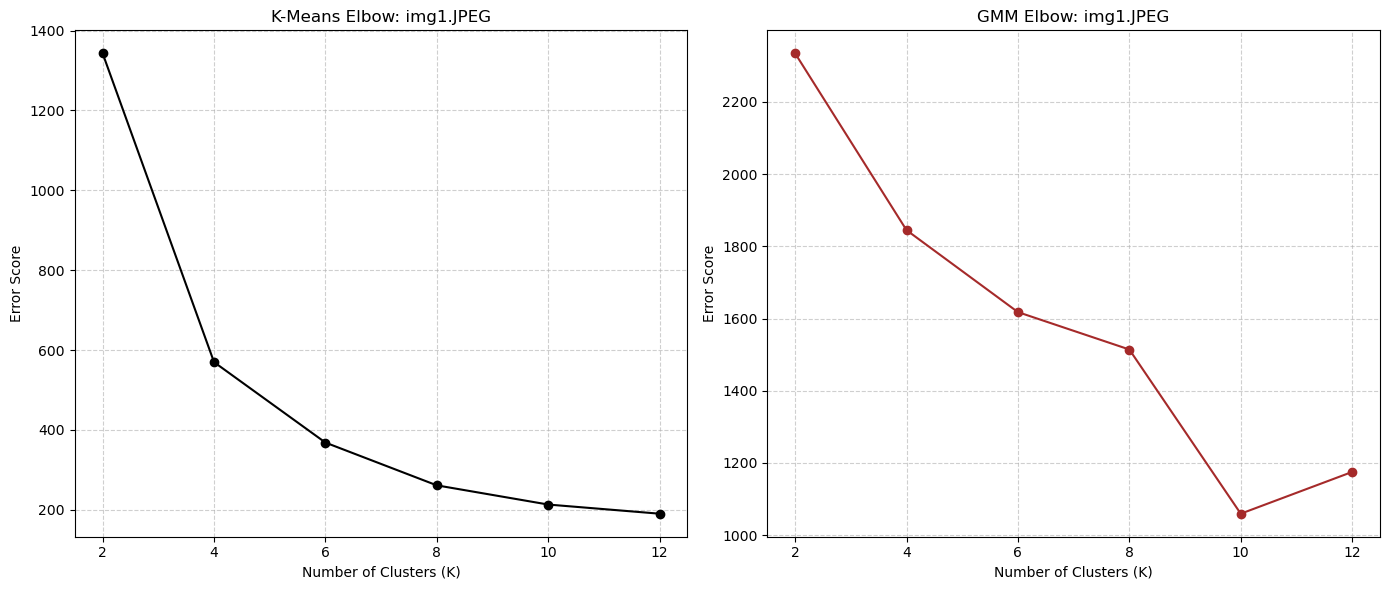

Generating Elbow Plots For: img2.JPEG
  Testing K-Means k=2
  Testing K-Means k=4
  Testing K-Means k=6
  Testing K-Means k=8
  Testing K-Means k=10
  Testing K-Means k=12
  Testing GMM k=2
  Testing GMM k=4
  Testing GMM k=6
  Testing GMM k=8
  Testing GMM k=10
  Testing GMM k=12


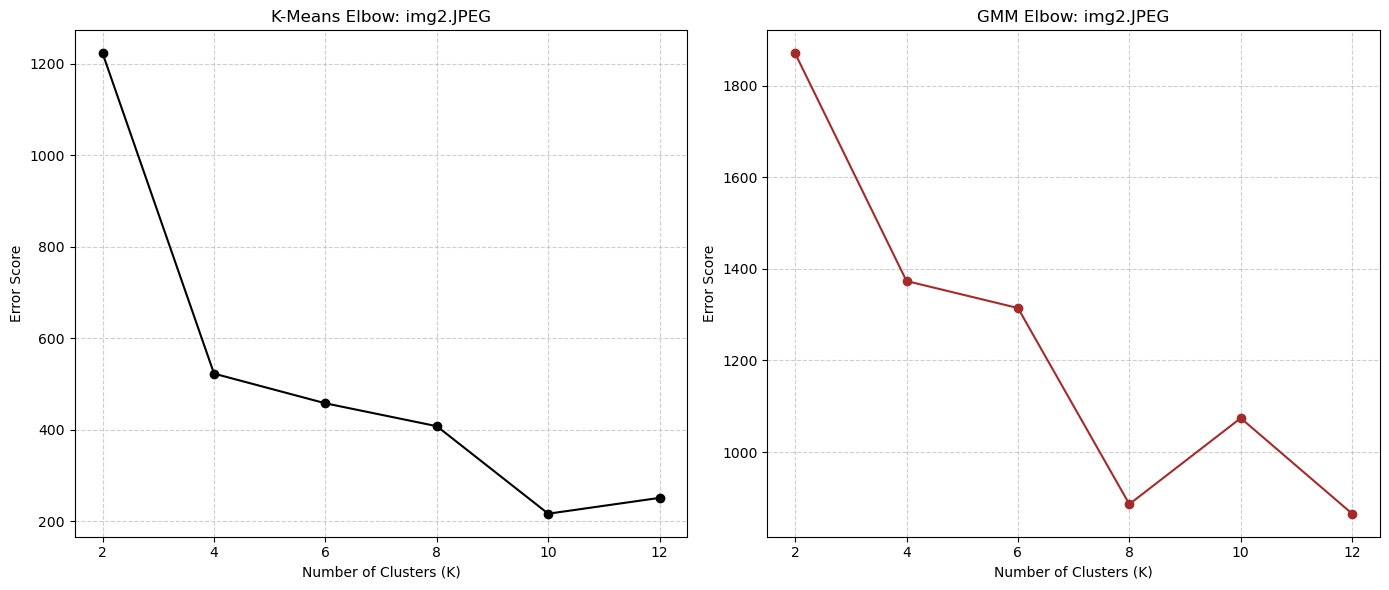

Generating Elbow Plots For: img3.JPEG
  Testing K-Means k=2
  Testing K-Means k=4
  Testing K-Means k=6
  Testing K-Means k=8
  Testing K-Means k=10
  Testing K-Means k=12
  Testing GMM k=2
  Testing GMM k=4
  Testing GMM k=6
  Testing GMM k=8
  Testing GMM k=10
  Testing GMM k=12


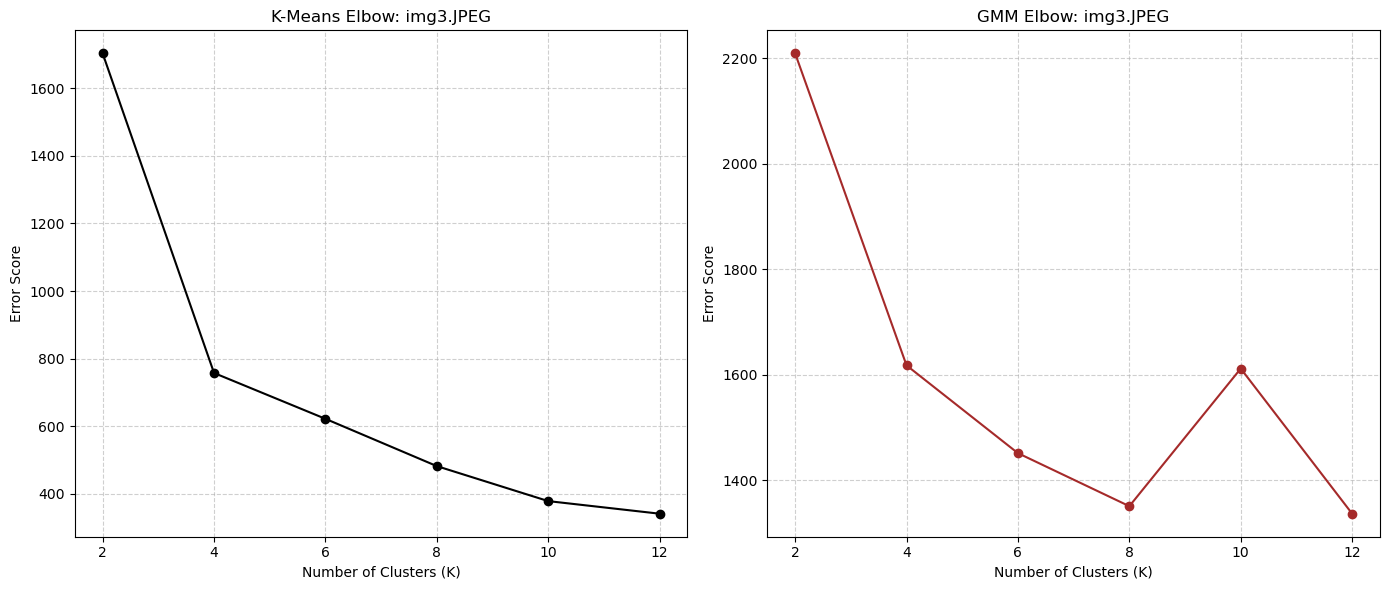

Generating Elbow Plots For: img4.JPEG
  Testing K-Means k=2
  Testing K-Means k=4
  Testing K-Means k=6
  Testing K-Means k=8
  Testing K-Means k=10
  Testing K-Means k=12
  Testing GMM k=2
  Testing GMM k=4
  Testing GMM k=6
  Testing GMM k=8
  Testing GMM k=10
  Testing GMM k=12


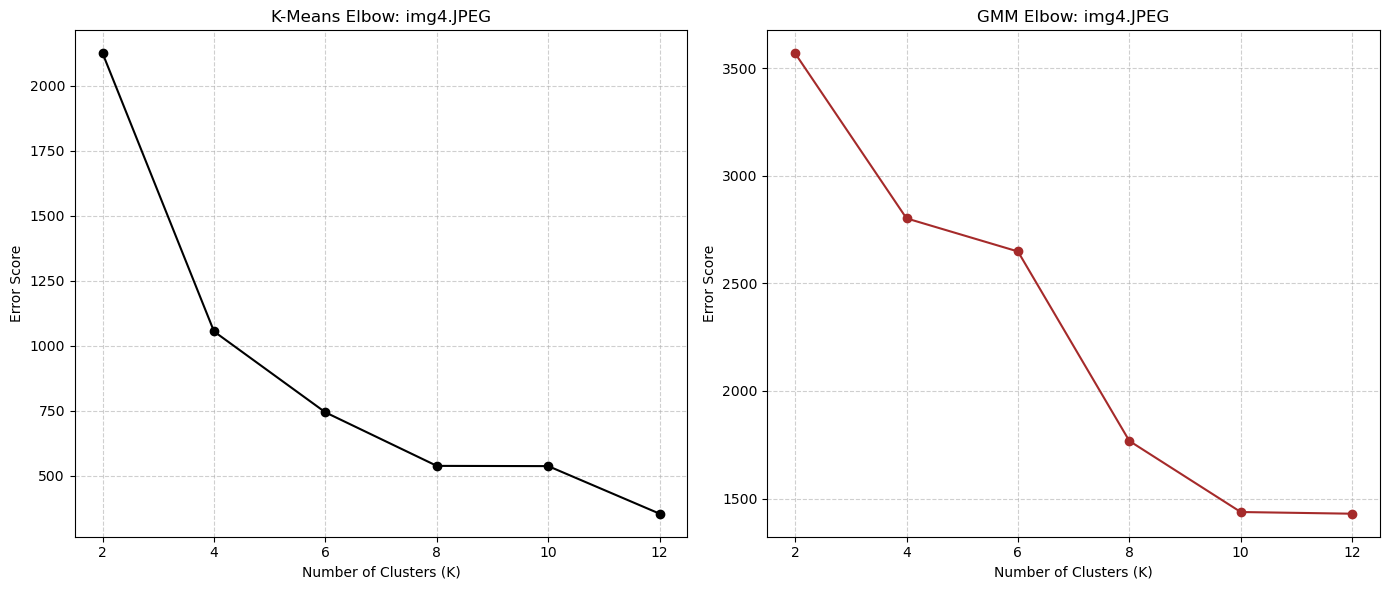

Generating Elbow Plots For: img5.JPEG
  Testing K-Means k=2
  Testing K-Means k=4
  Testing K-Means k=6
  Testing K-Means k=8
  Testing K-Means k=10
  Testing K-Means k=12
  Testing GMM k=2
  Testing GMM k=4
  Testing GMM k=6
  Testing GMM k=8
  Testing GMM k=10
  Testing GMM k=12


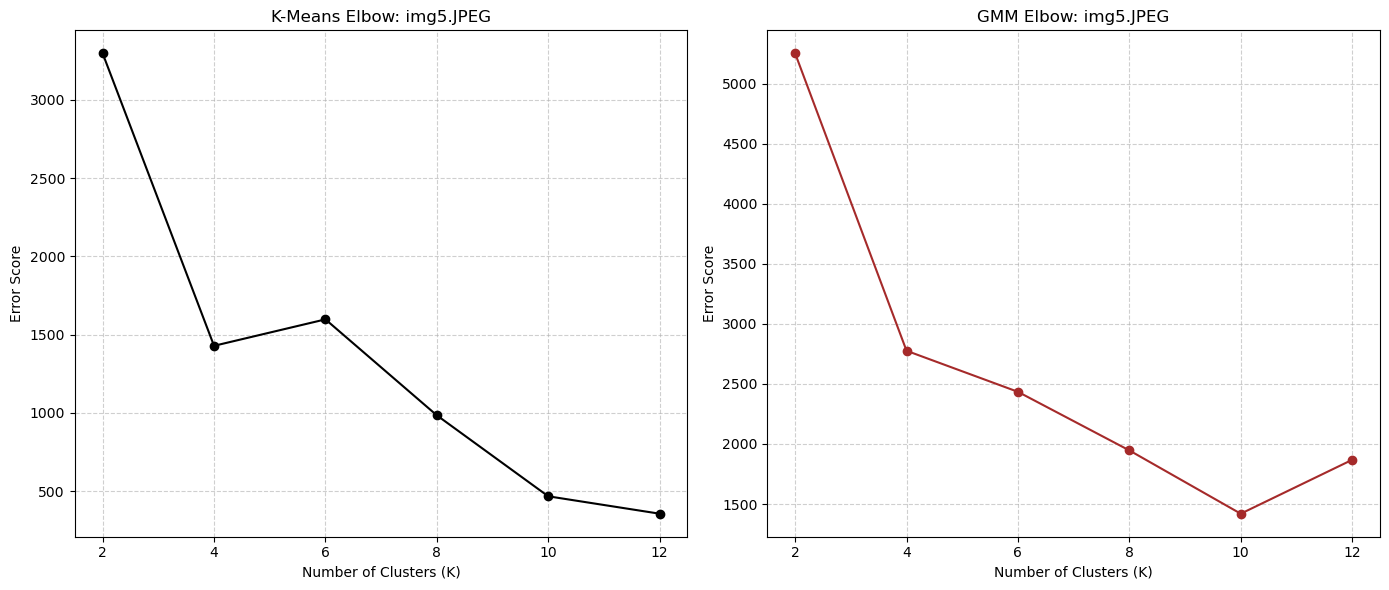

In [ ]:
import os
# I am listing all image filenames here
image_files_names=["img1.JPEG","img2.JPEG","img3.JPEG","img4.JPEG","img5.JPEG"]
k_to_test=[2,4,6,8,10,12]
# Now I will process each image at a time to plot elbow plot

for file_name in image_files_names:
    print(f"Generating Elbow Plots For: {file_name}")
    my_img = Image.open(file_name)
    img_as_array = np.array(my_img)/255.0
    pixel_list = img_as_array.reshape(-1, 3)

    #Now I am doing 20% sampling for speed
    small_pixel_list = []
    for i in range(len(pixel_list)):
        if i % 5 == 0:
            small_pixel_list.append(pixel_list[i])
    small_pixel_list = np.array(small_pixel_list)

    # K-Means Elbow
    errors = []
    for k_val in k_to_test:
        print(f"  Testing K-Means k={k_val}")
        # Performing 3 trials for K-Means to find a reliable error score for the Elbow Method
        # Since K-Means is sensitive to initial centroids, averaging 3 runs prevents spikes in the graph
        temp_trial_errors=[]
        # I am taking average over three iterations so that our plot can be smooth
        for _ in range(3):
            # Testing K-Means with a specific K to calculate the reconstruction error (SSE)
            # small_pixel_list: Using 20% sampled pixels to speed up the Elbow Plot generation
            # k_val: The current number of clusters being tested (from 2 to 12)
            # total_rounds=5: Using fewer iterations since we only need a rough error estimate for the elbow
            # centers: The final "average" colors (RGB) found for each of the K groups.
            # assignments: The tag/index for every pixel telling me which center it belongs to.
            # err: The error score used as the Y-axis in our K-Means Elbow Plot
            # iterkm/itergmm: The actual number of rounds it took for the colors to stop moving.
            centers, assignments, err, iterkm = K_Means_from_scratch(small_pixel_list, k_val, total_rounds=5)
            temp_trial_errors.append(err)
        # Now I am Calculating the mean error across the 3 trials for a more stable Elbow Plot
        average_err=np.mean(temp_trial_errors)
        errors.append(average_err)
    

    # GMM Elbow
    gmm_errors_list = []
    for k_val in k_to_test:
        print(f"  Testing GMM k={k_val}")
        temp_trial_errors=[]
        # Now I am running three trials so that I can better idea out elbow plot
        for _ in range(3):
            # Evaluating GMM for a specific K-value to determine the optimal number of components
            # We use the sampled pixel list to ensure the GMM calculations remain computationally feasible
            # small_pixel_list: This is my "sampled" data (10% or 12.5% of the image).
            # total_rounds=5: Limiting rounds here allows us to test multiple K values quickly
            # k_val: The current number of clusters being tested (from 2 to 12)
            # centers: The final "average" colors (RGB) found for each of the K groups.
            # assignments: The tag/index for every pixel telling me which center it belongs to.
            # err: The reconstruction error used to identify the "elbow" point for GMM
            # itergmm: Monitoring how many EM steps were performed in this short trial
            centers, assignments, err, itergmm = GMM_from_scratch(small_pixel_list, k_val, total_rounds=5)
            temp_trial_errors.append(err)
        average_err=np.mean(temp_trial_errors)
        gmm_errors_list.append(average_err)
            
        
    # Now I am creating a side-by-side figure for both Elbow plots
    plt.figure(figsize=(14, 6))

    #Now I am plotting K-Means Elbow Plot
    plt.subplot(1, 2, 1)
    plt.plot(k_to_test, errors, marker='o', color='black')
    plt.title(f"K-Means Elbow: {file_name}")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Error Score")
    plt.grid(True, linestyle='--', alpha=0.6)

    # Now I am plotting GMM Elbow Plot
    plt.subplot(1, 2, 2)
    plt.plot(k_to_test, gmm_errors_list, marker='o', color='brown')
    plt.title(f"GMM Elbow: {file_name}")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Error Score")
    plt.grid(True, linestyle='--', alpha=0.6)

    
    plt.tight_layout()

    
    plt.savefig(f"{file_name}_SideBySide_Elbow.png")
    
    #
    plt.show()


 Reconstructing image for optimal value of K : img1.JPEG
K-Means Converged at round 35


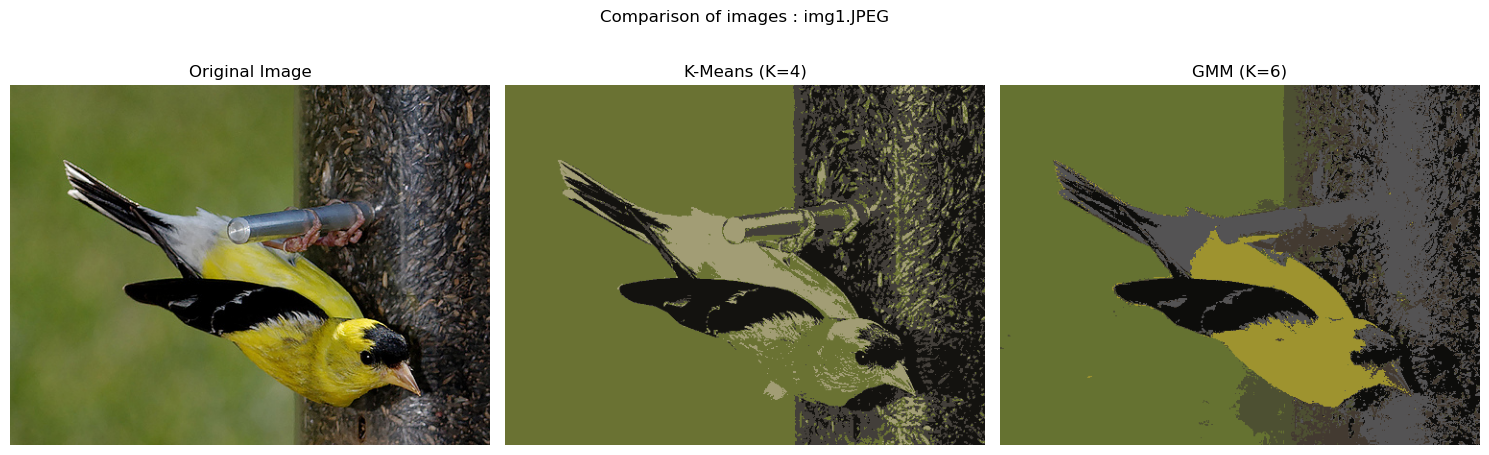


 Reconstructing image for optimal value of K : img2.JPEG


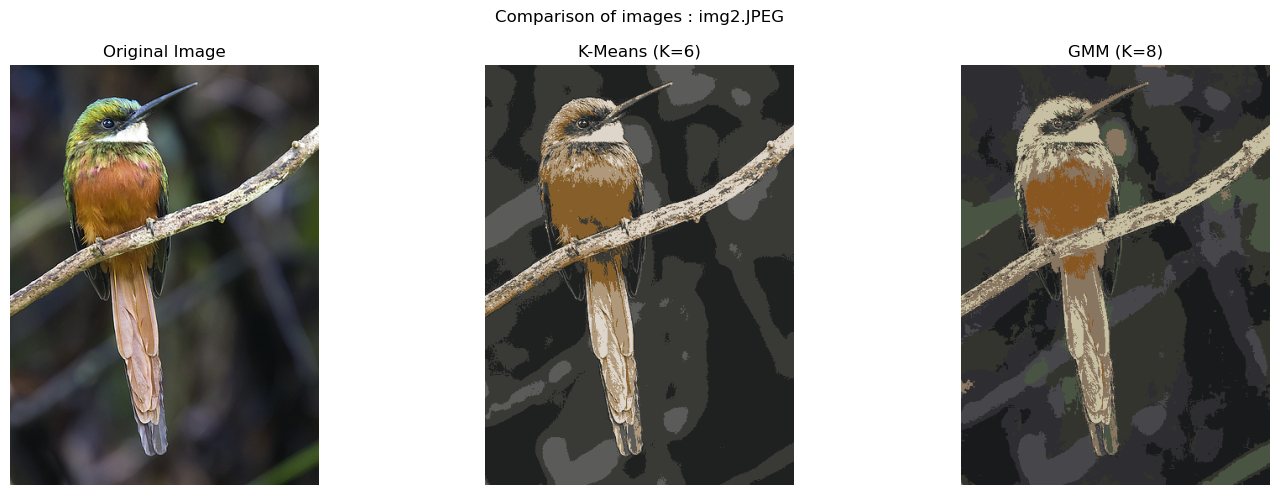


 Reconstructing image for optimal value of K : img3.JPEG
K-Means Converged at round 57


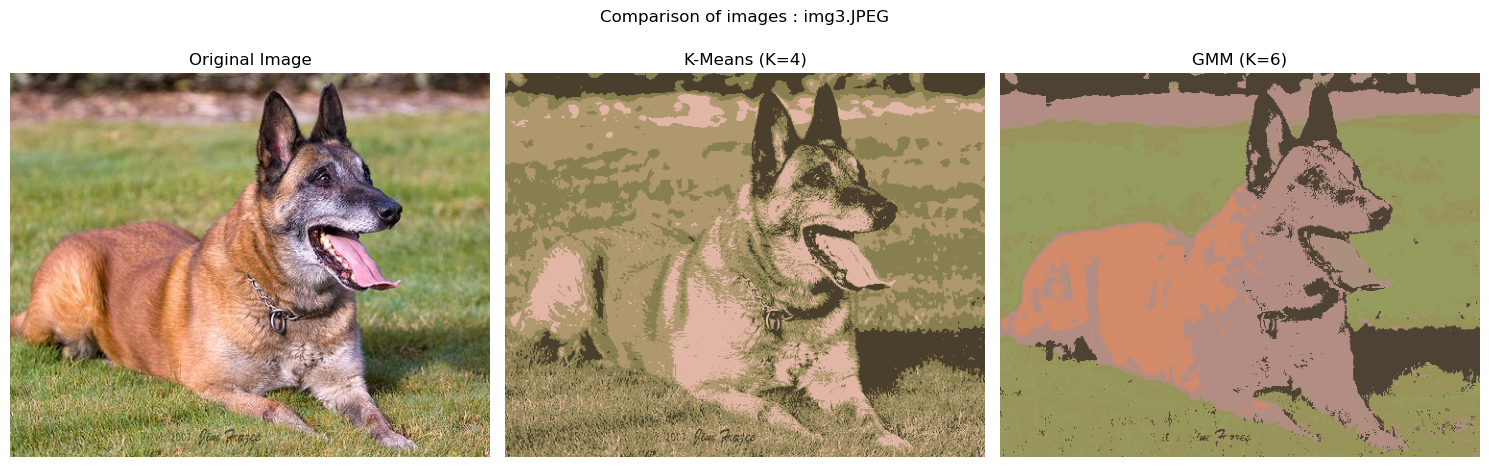


 Reconstructing image for optimal value of K : img4.JPEG
K-Means Converged at round 41


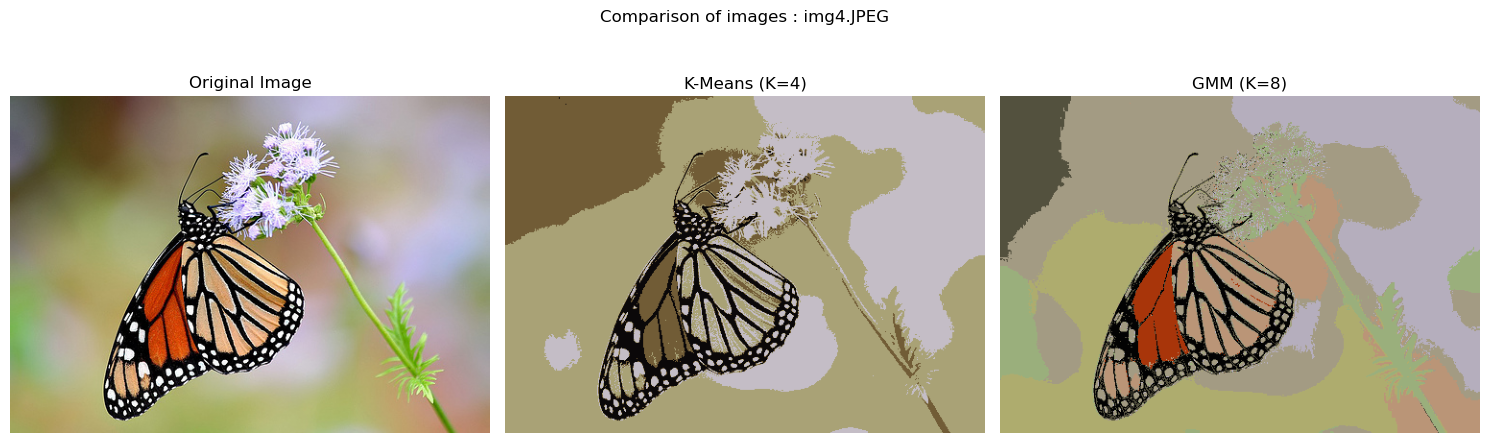


 Reconstructing image for optimal value of K : img5.JPEG
GMM Converged early at round 95


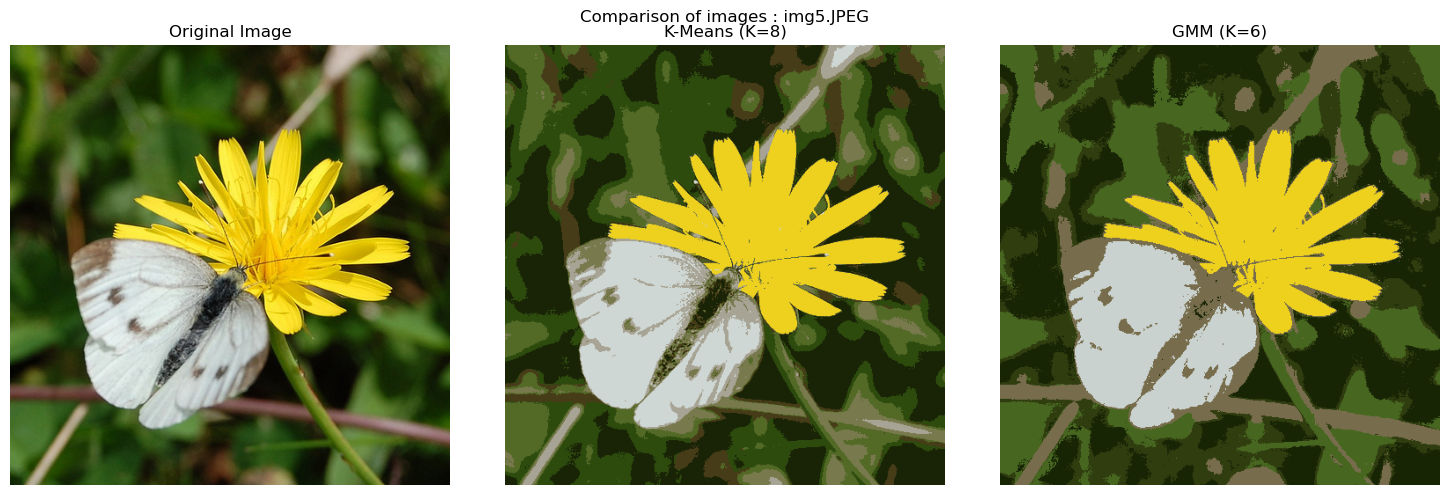


Finished processing all images


In [ ]:

optimal_k_values = {
    "img1.JPEG": {"k_means": 4, "gmm": 6},
    "img2.JPEG": {"k_means": 6, "gmm": 8},
    "img3.JPEG": {"k_means": 4, "gmm": 6},
    "img4.JPEG": {"k_means": 4, "gmm": 8},
    "img5.JPEG": {"k_means": 8,"gmm": 6}
}

for file_name in image_files_names:
    print(f"\n Reconstructing image for optimal value of K : {file_name}")
    my_img = Image.open(file_name)
    img_as_array = np.array(my_img)/255.0
    height, width, channels = img_as_array.shape
    pixel_list = img_as_array.reshape(-1, 3)

    
    my_k = optimal_k_values[file_name]["k_means"]
    # Calling K-Means on the full image to get final colors and tags
    # pixel_list: The complete list of RGB pixels from the image
    # my_k: The optimal number of clusters I found from the elbow plot
    # total_rounds: The max iterations allowed for the final run (100)

    #final_centers: The K representative RGB colors found by the algorithm
    #final_tags: The center index assigned to every single pixel
    #final_err: The total squared error for the reconstructed image
    #iterkm: The actual number of rounds it took to converge
    final_centers, final_tags, final_err, iterkm = K_Means_from_scratch(pixel_list, my_k, total_rounds=100)
    rebuilt_img = final_centers[final_tags].reshape(height, width, channels)
    
    # 2. Reconstructing image with  GMM for two different initializations 
    
    my_gmm_k = optimal_k_values[file_name]["gmm"]
    # Calling GMM on the full image to get the final blob centers and tags
    # pixel_list: The full array of pixels from the original image
    # my_gmm_k: The optimal number of blobs I picked from the GMM elbow plot
    # Input - total_rounds: Maximum iterations allowed for the EM process (100)

    # final_gmm_centers: The final mean RGB colors for each Gaussian blob
    # final_gmm_tags: The index of the best blob assigned to every pixel
    # gmm_total_err: The total squared error for the GMM reconstruction
    # itergmm: The actual number of rounds it took for GMM to converge
    final_gmm_centers, final_gmm_tags, gmm_total_err, itergmm = GMM_from_scratch(pixel_list, my_gmm_k, total_rounds=100)
    gmm_rebuilt_img = final_gmm_centers[final_gmm_tags].reshape(height, width, channels)

    # Now I am displaying results
    # 
    plt.figure(figsize=(15, 5))
    
    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(img_as_array)
    plt.title("Original Image")
    plt.axis('off') 
    
    # 2.  K-Means result
    plt.subplot(1, 3, 2)
    plt.imshow(rebuilt_img)
    plt.title(f"K-Means (K={my_k})")
    plt.axis('off') 
    
    # 3. GMM result
    plt.subplot(1, 3, 3)
    plt.imshow(gmm_rebuilt_img)
    plt.title(f"GMM (K={my_gmm_k})")
    plt.axis('off')

    
    plt.suptitle(f"Comparison of images : {file_name}")
    plt.tight_layout()
    
    
    plt.savefig(f"{file_name}_Algorithm_Comparison.png")
    
    
    plt.show()

print("\nFinished processing all images")

In [9]:
# import os
# # I am listing all image filenames here
# image_files_names=["img1.JPEG","img2.JPEG","img3.JPEG","img4.JPEG","img5.JPEG"]
# k_to_test=[2,4,6,8,10]
# for file_name in image_files_names:
#     print(f"STARTING ANALYSIS FOR: {file_name}")
#     #Now I am doing data prepration
#     my_img=Image.open(file_name)
#     img_as_array=np.array(my_img)/255.0
#     height=img_as_array.shape[0]
#     width=img_as_array.shape[1]
#     channels=img_as_array.shape[2]


# # Now I will put all pixel in one long list
#     pixel_list=[]
#     for h in range(height):
#         for w in range(width):
#             pixel_list.append(img_as_array[h,w])
#     pixel_list=np.array(pixel_list)
#     # Now I am creating a smaller list for the elbow plot so it doesn't take a lot of time
#     small_pixel_list = []
    
#     for i in range(len(pixel_list)):
#         # I am only picking every 10th pixel (10% sampling)
#         if i % 8 == 0:
#             small_pixel_list.append(pixel_list[i])
#     small_pixel_list = np.array(small_pixel_list)
    
#     errors=[]
#     for k_val in k_to_test:
#         print(f"Testing K-Means k={k_val} for {file_name}")
#         #Using few rounds for the elbow check so it doesn't take too long
#         centers, assignments, err, iterkm = K_Means_from_scratch(small_pixel_list, k_val, total_rounds=5)
#         errors.append(err)
#     plt.plot(k_to_test,errors,marker='o',color='red')
#     plt.title(f"K-Means Elbow: {file_name}")
#     plt.xlabel("Number of Groups")
#     plt.ylabel("Error Score")
#     plt.savefig(f"{file_name} Elbow Plot K-Means.png")
#     plt.show()
    
#     user_k = input(f"Based on the plot for {file_name}, enter optimal K for K-Means: ")
#     my_k = int(user_k)
#     #Now I am reconstructing the image
#     print(f"Reconstructing {file_name} with K-Means (K={my_k})")
#     final_centers,final_tags,final_err, iterkm =K_Means_from_scratch(pixel_list,my_k,total_rounds=100)
#     print(f"Iterations to converge in case K_Means is {iterkm}")
#     # Now I am creating the new image by replacing each pixel with it's center color
#     # new_pixels=[]
#     # for t in range(len(final_tags)):
#     #     new_pixels.append(final_centers[final_tags[t]])

#     # rebuilt_img=np.array(new_pixels).reshape(height,width,channels)
    
#     rebuilt_img = final_centers[final_tags].reshape(height, width, channels)

#     # Now I am doing quality checks
#     psnr_val=check_psnr(img_as_array,rebuilt_img,data_range=1.0)
#     ssim_val=check_ssim(img_as_array,rebuilt_img,channel_axis=2,data_range=1.0)
#     print(f"K-Means Results - PSNR: {psnr_val:.2f}, SSIM: {ssim_val:.4f}")


#     plt.subplot(1,2,1)
#     plt.imshow(img_as_array)
#     plt.title("Original")
#     plt.subplot(1,2,2)
#     plt.imshow(rebuilt_img)
#     plt.title(f"K-Means K={my_k}")
#     plt.savefig(f" {file_name}_KMeans_Rebuilt.png")
#     plt.show()
# # Now I am implementing GMM
#     gmm_errors_list = []

#     for k_val in k_to_test:
#         print(f"Testing GMM k={k_val} for {file_name}")
#         # I'm using 5 rounds here so it runs faster for the elbow check
#         centers,assignments,err,itergmm= GMM_from_scratch(small_pixel_list, k_val, total_rounds=5)
#         gmm_errors_list.append(err)

#     # Drawing the plot
#     plt.plot(k_to_test, gmm_errors_list, marker='o', color='blue')
#     plt.title(f"GMM Elbow: {file_name}")
#     plt.xlabel("Number of Groups (K)")
#     plt.ylabel("Error Score")
#     plt.savefig(f"{file_name} Elbow Plot GMM.png")
#     plt.show()

#     user_gmm_k = input(f"Based on the plot for {file_name}, enter optimal K for GMM: ")
#     my_gmm_k = int(user_gmm_k)

#     # Now I am reconstructing the image using the chosen K value
#     print(f"Reconstructing {file_name} with GMM (K={my_gmm_k})")
#     final_gmm_centers, final_gmm_tags, gmm_total_err, itergmm = GMM_from_scratch(pixel_list, my_gmm_k, total_rounds=100)
#     print(f"Iterations to converge in case GMM is {itergmm}")
#     #Now I am creating the new pixels list for the image
#     # new_gmm_pixels = []
#     # for t in range(len(final_gmm_tags)):
#     #     # Now I am replacing the pixel with its corresponding blob center color
#     #     new_gmm_pixels.append(final_gmm_centers[final_gmm_tags[t]])

#     # # Now I am putting the image back into its 3D shape
#     # gmm_rebuilt_img = np.array(new_gmm_pixels).reshape(height, width, channels)
#     gmm_rebuilt_img = final_gmm_centers[final_gmm_tags].reshape(height, width, channels)
#     # Now I am doing the quality checks (assuming check_psnr and check_ssim are imported)
#     gmm_psnr = check_psnr(img_as_array, gmm_rebuilt_img, data_range=1.0)
#     gmm_ssim = check_ssim(img_as_array, gmm_rebuilt_img, channel_axis=2, data_range=1.0)

#     print(f"GMM Results - PSNR: {gmm_psnr:.2f}, SSIM: {gmm_ssim:.4f}")

#     # Now I am plotting original vs GMM version
#     plt.subplot(1, 2, 1)
#     plt.imshow(img_as_array)
#     plt.title("Original")

#     plt.subplot(1, 2, 2)
#     plt.imshow(gmm_rebuilt_img)
#     plt.title(f"GMM K={my_gmm_k}")
#     plt.savefig("Rebuilt with GMM.png")
#     plt.savefig(f" {file_name} GMM_Rebuilt_.png")

#     plt.show()
# print("\nFinished processing all images")

Task 3. With the optimal (k) from part 2, run K-Means and GMM using at least two different initialization. For each initialization and algorithm, record the iterations-to-converge, reconstruct the image, and compute PSNR and SSIM versus the original. Present the reconstructed images, and summarize differences in convergence speed and image quality across initializations.



TASK 3: Initialization checking for : img1.JPEG

 Starting Run_1 for img1.JPEG
K-Means initial colors for intializations 1 & 2 for k=4:
[[0.15686275 0.16078431 0.16862745]
 [0.40392157 0.42352941 0.19607843]
 [0.34117647 0.4        0.14509804]
 [0.6627451  0.58823529 0.1254902 ]]
K-Means Converged at round 45

 GMM Initialization 1 & 2 Blob Centers for k=6:
[[0.41960784 0.4745098  0.23529412]
 [0.43921569 0.49803922 0.22745098]
 [0.11764706 0.09411765 0.10196078]
 [0.41568627 0.44705882 0.21176471]
 [0.71764706 0.68627451 0.29019608]
 [0.44313725 0.48235294 0.24705882]]
GMM Converged early at round 139

 Starting Run_2 for img1.JPEG
K-Means initial colors for intializations 1 & 2 for k=4:
[[0.38039216 0.42352941 0.15686275]
 [0.35294118 0.42745098 0.10980392]
 [0.65098039 0.63921569 0.22745098]
 [0.06666667 0.06666667 0.05882353]]
K-Means Converged at round 37

 GMM Initialization 1 & 2 Blob Centers for k=6:
[[0.48627451 0.31372549 0.36470588]
 [0.54117647 0.46666667 0.06666667]
 [0.0

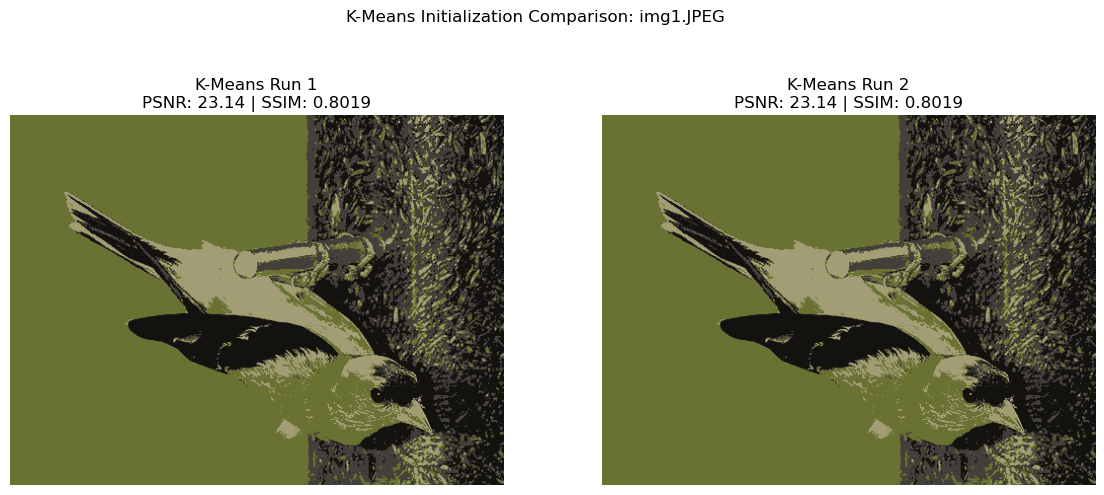

K-Means Results for img1.JPEG:
  Run 1 -> PSNR: 23.14, SSIM: 0.8019
  Run 2 -> PSNR: 23.14, SSIM: 0.8019


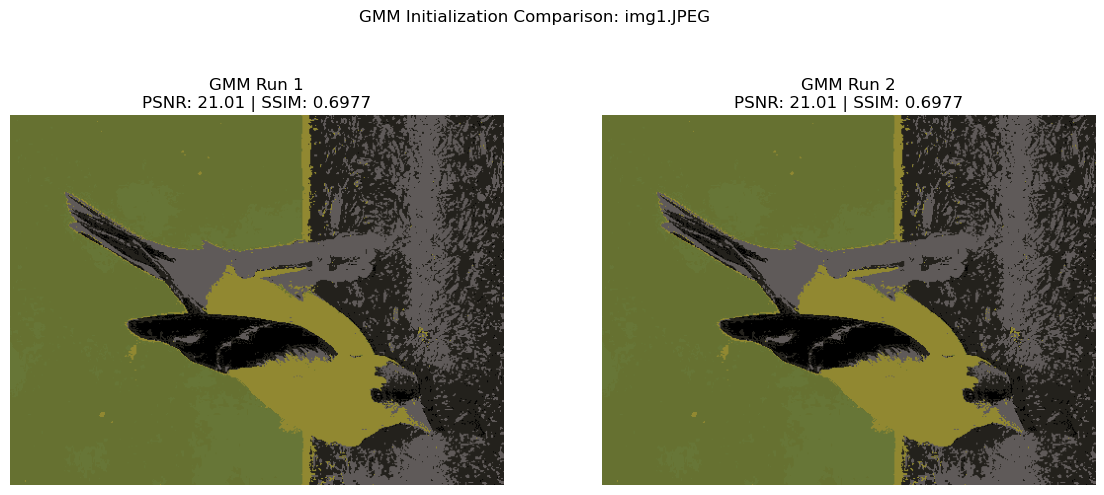

GMM Results for img1.JPEG:
  Run 1 -> PSNR: 21.01, SSIM: 0.6977
  Run 2 -> PSNR: 21.01, SSIM: 0.6977
------------------------------

TASK 3: Initialization checking for : img2.JPEG

 Starting Run_1 for img2.JPEG
K-Means initial colors for intializations 1 & 2 for k=6:
[[0.66666667 0.6627451  0.58039216]
 [0.14117647 0.14117647 0.14901961]
 [0.2627451  0.2745098  0.29411765]
 [0.28235294 0.27058824 0.19607843]
 [0.06666667 0.08235294 0.09411765]
 [0.15686275 0.16862745 0.19607843]]
K-Means Converged at round 133

 GMM Initialization 1 & 2 Blob Centers for k=8:
[[0.0745098  0.07843137 0.09411765]
 [0.8627451  0.74117647 0.67058824]
 [0.2627451  0.27843137 0.28235294]
 [0.16470588 0.16470588 0.17254902]
 [0.1372549  0.15686275 0.12941176]
 [0.11372549 0.12156863 0.10980392]
 [0.14901961 0.16862745 0.15294118]
 [0.12941176 0.14901961 0.13333333]]

 Starting Run_2 for img2.JPEG
K-Means initial colors for intializations 1 & 2 for k=6:
[[0.20392157 0.21960784 0.23137255]
 [0.18039216 0.168627

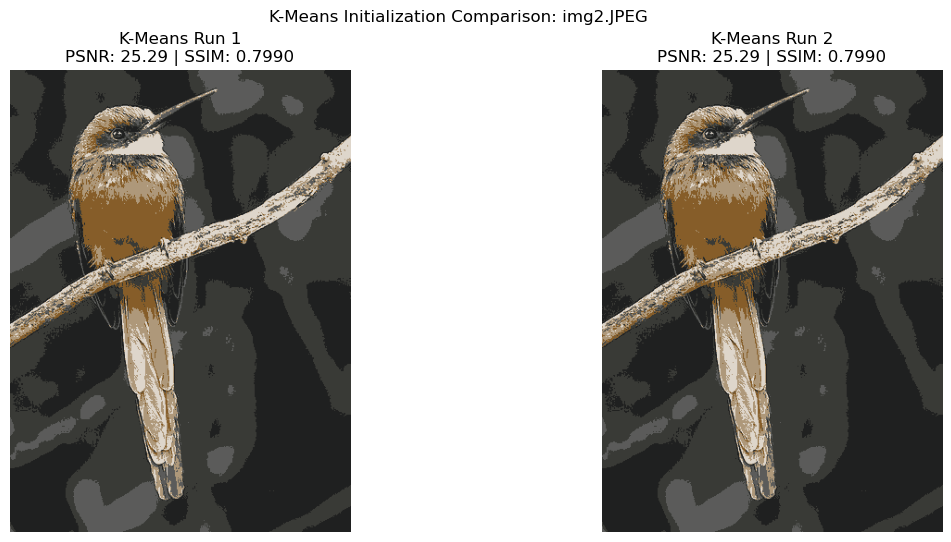

K-Means Results for img2.JPEG:
  Run 1 -> PSNR: 25.29, SSIM: 0.7990
  Run 2 -> PSNR: 25.29, SSIM: 0.7990


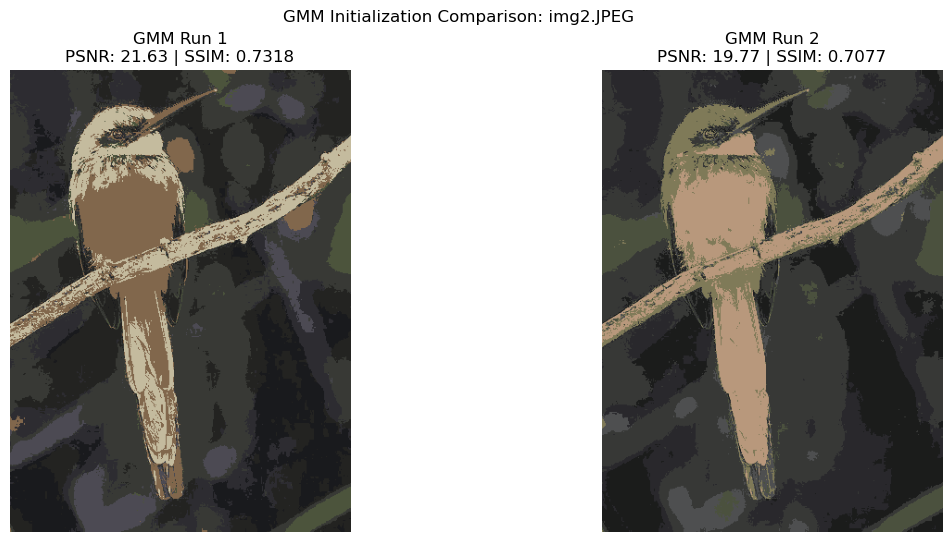

GMM Results for img2.JPEG:
  Run 1 -> PSNR: 21.63, SSIM: 0.7318
  Run 2 -> PSNR: 19.77, SSIM: 0.7077
------------------------------

TASK 3: Initialization checking for : img3.JPEG

 Starting Run_1 for img3.JPEG
K-Means initial colors for intializations 1 & 2 for k=4:
[[0.60784314 0.64313725 0.39607843]
 [0.78039216 0.60392157 0.51372549]
 [0.38823529 0.38431373 0.26666667]
 [0.22352941 0.16862745 0.25882353]]
K-Means Converged at round 54

 GMM Initialization 1 & 2 Blob Centers for k=6:
[[0.56862745 0.50588235 0.64705882]
 [0.30588235 0.33333333 0.20392157]
 [0.76862745 0.47058824 0.32941176]
 [0.68627451 0.69019608 0.45490196]
 [0.76470588 0.44705882 0.23137255]
 [0.55686275 0.6        0.29411765]]
GMM Converged early at round 412

 Starting Run_2 for img3.JPEG
K-Means initial colors for intializations 1 & 2 for k=4:
[[0.61176471 0.47843137 0.44313725]
 [0.47843137 0.48235294 0.25882353]
 [0.80784314 0.70980392 0.45882353]
 [0.96470588 0.6627451  0.44313725]]
K-Means Converged at rou

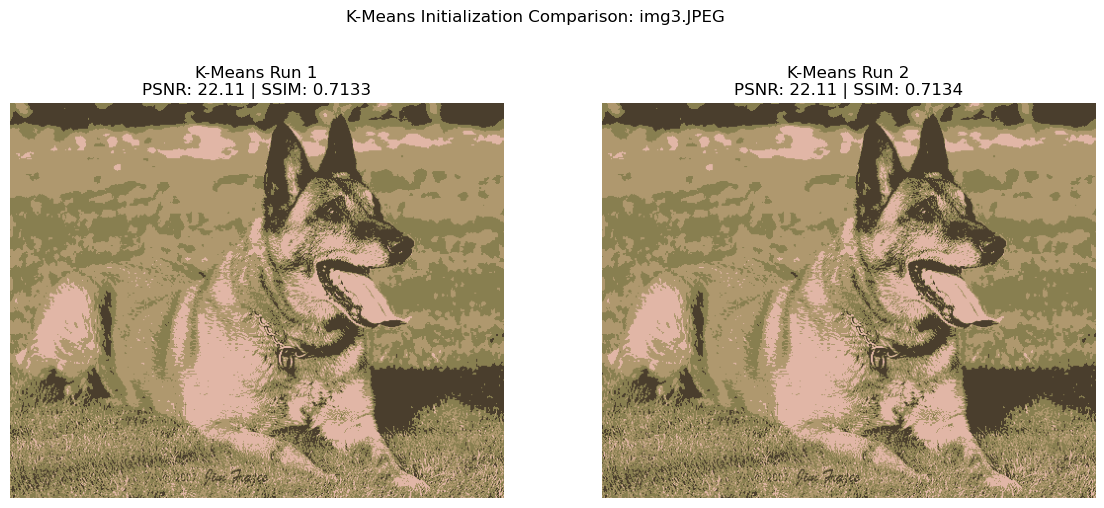

K-Means Results for img3.JPEG:
  Run 1 -> PSNR: 22.11, SSIM: 0.7133
  Run 2 -> PSNR: 22.11, SSIM: 0.7134


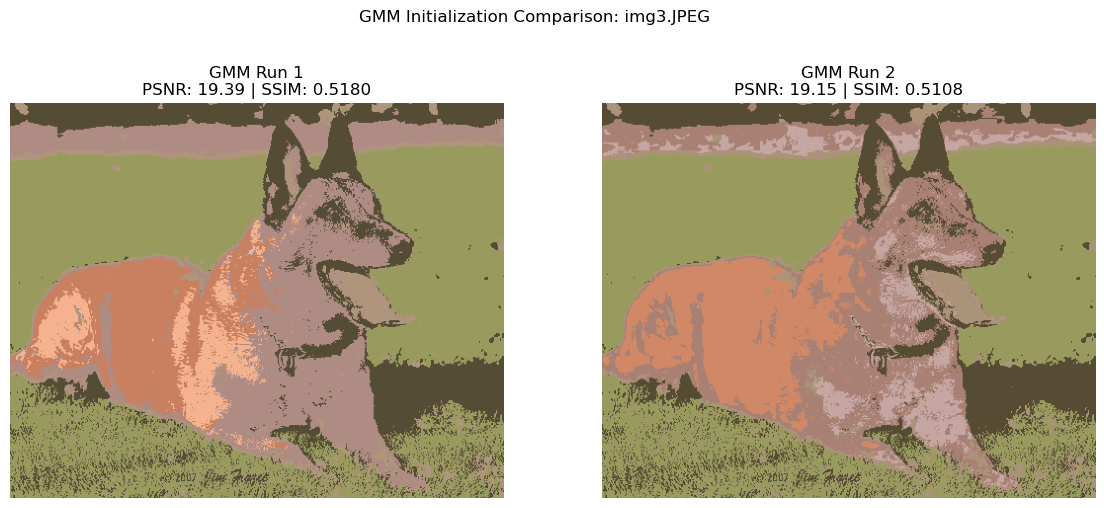

GMM Results for img3.JPEG:
  Run 1 -> PSNR: 19.39, SSIM: 0.5180
  Run 2 -> PSNR: 19.15, SSIM: 0.5108
------------------------------

TASK 3: Initialization checking for : img4.JPEG

 Starting Run_1 for img4.JPEG
K-Means initial colors for intializations 1 & 2 for k=4:
[[0.36078431 0.38039216 0.39215686]
 [0.67058824 0.60392157 0.50196078]
 [0.00784314 0.00784314 0.01568627]
 [0.6627451  0.63137255 0.37647059]]
K-Means Converged at round 18

 GMM Initialization 1 & 2 Blob Centers for k=8:
[[0.01960784 0.01568627 0.03529412]
 [0.56470588 0.55686275 0.4745098 ]
 [0.63137255 0.62745098 0.61176471]
 [0.70980392 0.6745098  0.67843137]
 [0.63921569 0.68627451 0.68627451]
 [0.74509804 0.69803922 0.60392157]
 [0.71764706 0.72156863 0.80392157]
 [0.60784314 0.61568627 0.53333333]]
GMM Converged early at round 174

 Starting Run_2 for img4.JPEG
K-Means initial colors for intializations 1 & 2 for k=4:
[[0.81568627 0.6745098  0.53333333]
 [0.73333333 0.7254902  0.81176471]
 [0.72156863 0.69411765 0

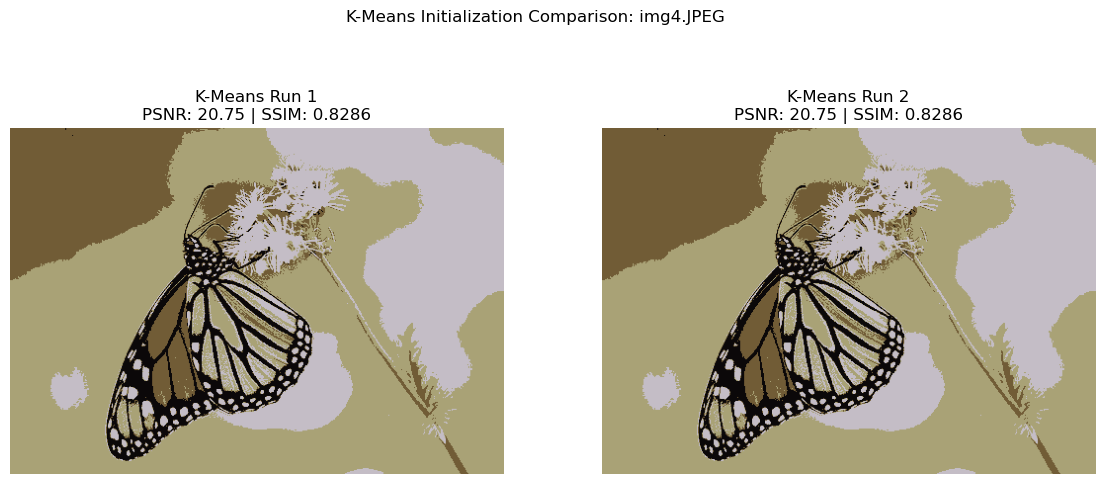

K-Means Results for img4.JPEG:
  Run 1 -> PSNR: 20.75, SSIM: 0.8286
  Run 2 -> PSNR: 20.75, SSIM: 0.8286


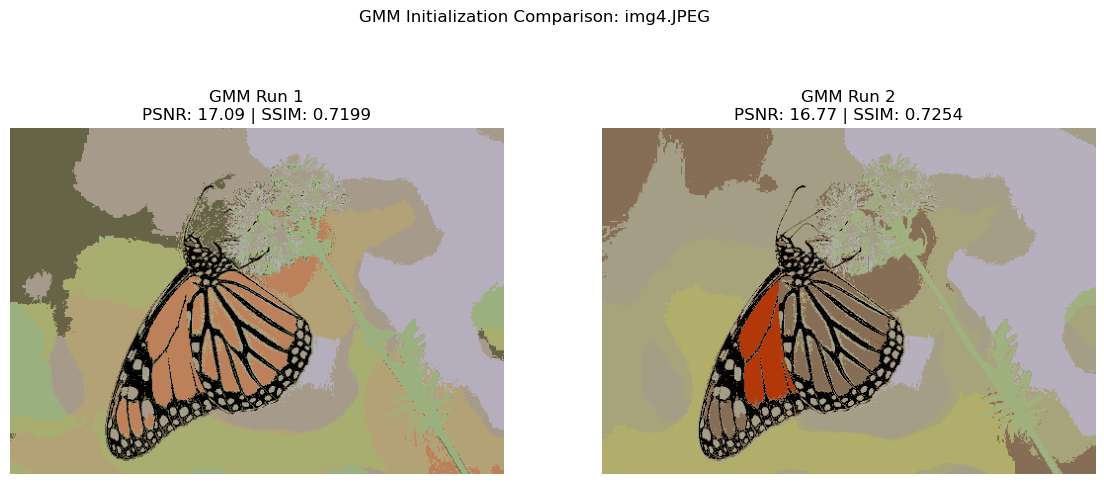

GMM Results for img4.JPEG:
  Run 1 -> PSNR: 17.09, SSIM: 0.7199
  Run 2 -> PSNR: 16.77, SSIM: 0.7254
------------------------------

TASK 3: Initialization checking for : img5.JPEG

 Starting Run_1 for img5.JPEG
K-Means initial colors for intializations 1 & 2 for k=8:
[[0.07843137 0.1372549  0.00784314]
 [0.98039216 0.85882353 0.20784314]
 [0.99215686 0.89411765 0.15686275]
 [0.09019608 0.0745098  0.02745098]
 [0.96470588 0.83921569 0.12941176]
 [0.08235294 0.06666667 0.01960784]
 [0.06666667 0.14509804 0.00784314]
 [0.63529412 0.63921569 0.61960784]]
K-Means Converged at round 48

 GMM Initialization 1 & 2 Blob Centers for k=6:
[[0.15294118 0.13333333 0.00784314]
 [0.27843137 0.26666667 0.10588235]
 [0.49019608 0.45882353 0.31764706]
 [0.85882353 0.70588235 0.        ]
 [0.42745098 0.42745098 0.28627451]
 [0.1254902  0.1372549  0.01568627]]
GMM Converged early at round 79

 Starting Run_2 for img5.JPEG
K-Means initial colors for intializations 1 & 2 for k=8:
[[0.99607843 0.92156863 0.

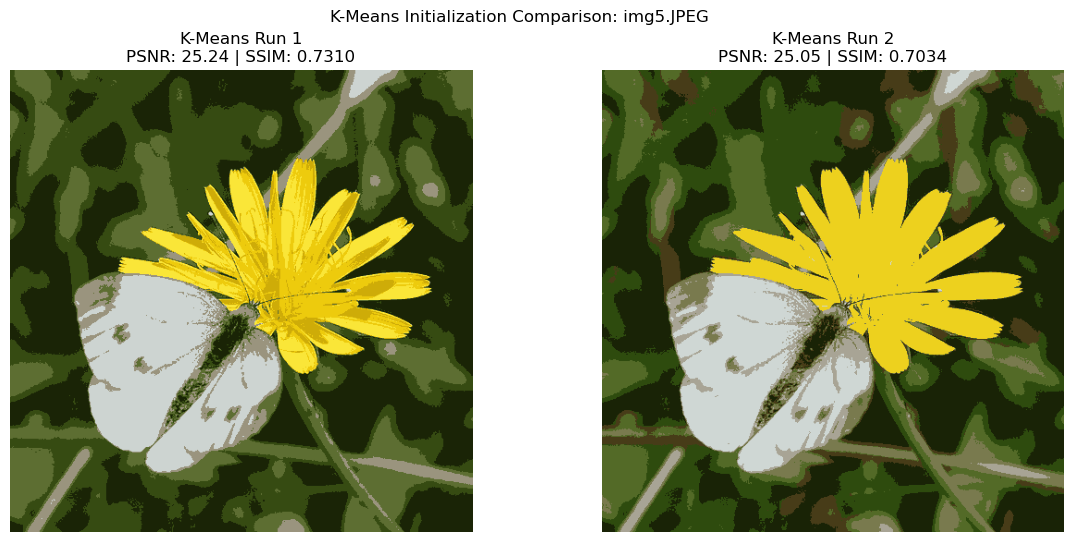

K-Means Results for img5.JPEG:
  Run 1 -> PSNR: 25.24, SSIM: 0.7310
  Run 2 -> PSNR: 25.05, SSIM: 0.7034


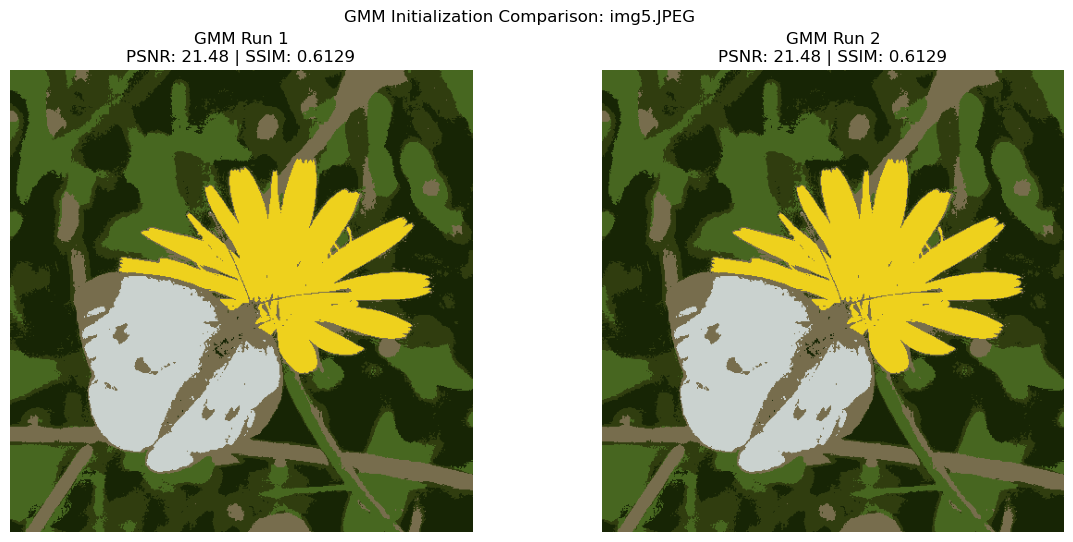

GMM Results for img5.JPEG:
  Run 1 -> PSNR: 21.48, SSIM: 0.6129
  Run 2 -> PSNR: 21.48, SSIM: 0.6129
------------------------------


In [14]:
image_files_names = ["img1.JPEG", "img2.JPEG", "img3.JPEG", "img4.JPEG", "img5.JPEG"]

for file_name in image_files_names:
    
    print(f"\nTASK 3: Initialization checking for : {file_name}")
    
    
    # Now I am doing data preparation exactly like I did in Task 2
    my_img = Image.open(file_name)
    img_as_array = np.array(my_img) / 255.0
    height = img_as_array.shape[0]
    width = img_as_array.shape[1]
    channels = img_as_array.shape[2]

    # Now I will put all pixel in one long list
    pixel_list = []
    for h in range(height):
        for w in range(width):
            pixel_list.append(img_as_array[h, w])
    pixel_list = np.array(pixel_list)
    
    # Now I am getting my optimal K values from the dictionary
    my_km_k = optimal_k_values[file_name]["k_means"]
    my_gmm_k = optimal_k_values[file_name]["gmm"]
    
    # I am using a dictionary to hold results from both runs so I can plot them side-by-side
    results_storage = {}

    for trial in ["Run_1", "Run_2"]:
        print(f"\n Starting {trial} for {file_name}")
        
         #K-MEANS WITH RANDOM INITIALIZATION
        # 
        # Running K-Means on the full image for Task 3 analysis
        # pixel_list: The complete list of pixels from the original image
        # my_km_k: The optimal K value I picked from the K-Means elbow plot
        # total_rounds: Set to 120 to trigger the printing of initial starting colors
        # 
        # km_centers: The final palette of K colors found by the algorithm
        # km_tags: The center index assigned to every single pixel for rebuilding
        # km_err: The total squared error for this final reconstruction
        # iterkm: The actual number of rounds taken to reach convergence
        km_centers, km_tags, km_err, iterkm = K_Means_from_scratch(pixel_list, my_km_k, total_rounds=500)
        km_rebuilt_img = km_centers[km_tags].reshape(height, width, channels)
        km_psnr = check_psnr(img_as_array, km_rebuilt_img, data_range=1.0)
        km_ssim = check_ssim(img_as_array, km_rebuilt_img, channel_axis=2, data_range=1.0)
        
        #GMM WITH RANDOM INITIALIZATION 
        # Running GMM on the full image for Task 3 analysis
        #Input
        # pixel_list: The complete list of pixels from the original image
        # my_gmm_k: The optimal number of blobs I picked from the GMM elbow plot
        # Input - total_rounds: Set to 500 to trigger the printing of initial blob centers
        # Output
        # gmm_centers: The final mean RGB colors for each Gaussian blob
        # gmm_tags: The index of the best blob assigned to every single pixel
        # gmm_err: The total squared error for this final GMM reconstruction
        # itergmm: The actual number of rounds taken to reach convergence
        gmm_centers, gmm_tags, gmm_err, itergmm = GMM_from_scratch(pixel_list, my_gmm_k, total_rounds=500)
        gmm_rebuilt_img = gmm_centers[gmm_tags].reshape(height, width, channels)
        gmm_psnr = check_psnr(img_as_array, gmm_rebuilt_img, data_range=1.0)
        gmm_ssim = check_ssim(img_as_array, gmm_rebuilt_img, channel_axis=2, data_range=1.0)

        # Storing images and metrics for the final comparison plot
        results_storage[trial] = {
            'km_img': km_rebuilt_img, 'km_metrics': (km_psnr, km_ssim),
            'gmm_img': gmm_rebuilt_img, 'gmm_metrics': (gmm_psnr, gmm_ssim)
        }
    
    
    # --- SIDE-BY-SIDE PLOTTING FOR K-MEANS ---
    plt.figure(figsize=(14, 6)) # Made slightly wider to fit extra text
    
    # Run 1 - K-Means
    plt.subplot(1, 2, 1)
    plt.imshow(results_storage["Run_1"]['km_img'])
    # Adding SSIM to the title here
    km_p1, km_s1 = results_storage['Run_1']['km_metrics']
    plt.title(f"K-Means Run 1\nPSNR: {km_p1:.2f} | SSIM: {km_s1:.4f}")
    plt.axis('off')

    # Run 2 - K-Means
    plt.subplot(1, 2, 2)
    plt.imshow(results_storage["Run_2"]['km_img'])
    km_p2, km_s2 = results_storage['Run_2']['km_metrics']
    plt.title(f"K-Means Run 2\nPSNR: {km_p2:.2f} | SSIM: {km_s2:.4f}")
    plt.axis('off')
    
    plt.suptitle(f"K-Means Initialization Comparison: {file_name}")
    plt.savefig(f"Comparison_KMeans_{file_name}.png")
    plt.show()

    # Printing the values to the console for your report logs
    print(f"K-Means Results for {file_name}:")
    print(f"  Run 1 -> PSNR: {km_p1:.2f}, SSIM: {km_s1:.4f}")
    print(f"  Run 2 -> PSNR: {km_p2:.2f}, SSIM: {km_s2:.4f}")

    # --- SIDE-BY-SIDE PLOTTING FOR GMM ---
    plt.figure(figsize=(14, 6))
    
    # Run 1 - GMM
    plt.subplot(1, 2, 1)
    plt.imshow(results_storage["Run_1"]['gmm_img'])
    gmm_p1, gmm_s1 = results_storage['Run_1']['gmm_metrics']
    plt.title(f"GMM Run 1\nPSNR: {gmm_p1:.2f} | SSIM: {gmm_s1:.4f}")
    plt.axis('off')

    # Run 2 - GMM
    plt.subplot(1, 2, 2)
    plt.imshow(results_storage["Run_2"]['gmm_img'])
    gmm_p2, gmm_s2 = results_storage['Run_2']['gmm_metrics']
    plt.title(f"GMM Run 2\nPSNR: {gmm_p2:.2f} | SSIM: {gmm_s2:.4f}")
    plt.axis('off')

    plt.suptitle(f"GMM Initialization Comparison: {file_name}")
    plt.savefig(f"Comparison_GMM_{file_name}.png")
    plt.show()

    # Printing GMM values to the console
    print(f"GMM Results for {file_name}:")
    print(f"  Run 1 -> PSNR: {gmm_p1:.2f}, SSIM: {gmm_s1:.4f}")
    print(f"  Run 2 -> PSNR: {gmm_p2:.2f}, SSIM: {gmm_s2:.4f}")
    print("-" * 30)
        

In [11]:
# #Comparing Different Initializations

# # Now I am defining the optimal K values I found from looking at the plots in Task 2





# image_files_names = ["img1.JPEG", "img2.JPEG", "img3.JPEG", "img4.JPEG", "img5.JPEG"]

# for file_name in image_files_names:
    
#     print(f"\nTASK 3: Initialization checking for : {file_name}")
    
    
#     # Now I am doing data preparation exactly like I did in Task 2
#     my_img = Image.open(file_name)
#     img_as_array = np.array(my_img) / 255.0
#     height = img_as_array.shape[0]
#     width = img_as_array.shape[1]
#     channels = img_as_array.shape[2]

#     # Now I will put all pixel in one long list
#     pixel_list = []
#     for h in range(height):
#         for w in range(width):
#             pixel_list.append(img_as_array[h, w])
#     pixel_list = np.array(pixel_list)
    
#     # Getting my optimal K values from the dictionary
#     my_km_k = optimal_k_values[file_name]["k_means"]
#     my_gmm_k = optimal_k_values[file_name]["gmm"]

#     # I am running two different trials to see how random starts change things
#     for trial in ["Run_1", "Run_2"]:
#         print(f"\n Starting {trial} for {file_name}")
        
#         #K-MEANS WITH RANDOM INITIALIZATION
#         # Input
#         # Running K-Means on the full image for Task 3 analysis
#         # pixel_list: The complete list of pixels from the original image
#         # my_km_k: The optimal K value I picked from the K-Means elbow plot
#         # total_rounds: Set to 120 to trigger the printing of initial starting colors
#         # Output
#         # km_centers: The final palette of K colors found by the algorithm
#         # km_tags: The center index assigned to every single pixel for rebuilding
#         # km_err: The total squared error for this final reconstruction
#         # iterkm: The actual number of rounds taken to reach convergence
#         km_centers, km_tags, km_err, iterkm = K_Means_from_scratch(pixel_list, my_km_k, total_rounds=120)
        
#         # Now I am creating the new image by replacing each pixel with it's center color
#         km_new_pixels = []
#         for t in range(len(km_tags)):
#             km_new_pixels.append(km_centers[km_tags[t]])
#         km_rebuilt_img = np.array(km_new_pixels).reshape(height, width, channels)
        
#         # Now I am doing quality checks
#         km_psnr = check_psnr(img_as_array, km_rebuilt_img, data_range=1.0)
#         km_ssim = check_ssim(img_as_array, km_rebuilt_img, channel_axis=2, data_range=1.0)
        
#         print(f"K-Means trail_({trial}) for {file_name} Results - Rounds: {iterkm}, PSNR: {km_psnr:.2f}, SSIM: {km_ssim}")

#         #GMM WITH RANDOM INITIALIZATION 
#         # Running GMM on the full image for Task 3 analysis
#         #Input
#         # pixel_list: The complete list of pixels from the original image
#         # my_gmm_k: The optimal number of blobs I picked from the GMM elbow plot
#         # Input - total_rounds: Set to 120 to trigger the printing of initial blob centers
#         # Output
#         # gmm_centers: The final mean RGB colors for each Gaussian blob
#         # gmm_tags: The index of the best blob assigned to every single pixel
#         # gmm_err: The total squared error for this final GMM reconstruction
#         # itergmm: The actual number of rounds taken to reach convergence
#         gmm_centers, gmm_tags, gmm_err, itergmm = GMM_from_scratch(pixel_list, my_gmm_k, total_rounds=120)
        
#         # Now I am creating the new pixels list for the GMM image
#         gmm_new_pixels = []
#         for t in range(len(gmm_tags)):
#             gmm_new_pixels.append(gmm_centers[gmm_tags[t]])
#         gmm_rebuilt_img = np.array(gmm_new_pixels).reshape(height, width, channels)
        
#         # Now I am doing the quality checks for GMM
#         gmm_psnr = check_psnr(img_as_array, gmm_rebuilt_img, data_range=1.0)
#         gmm_ssim = check_ssim(img_as_array, gmm_rebuilt_img, channel_axis=2, data_range=1.0)

#         print(f"GMM trail_({trial}) for {file_name} Results - Rounds: {itergmm}, PSNR: {gmm_psnr:.2f}, SSIM: {gmm_ssim}")

#         plt.figure(figsize=(10, 5))
        
#         # Displaying K-Means result
#         plt.subplot(1, 2, 1)
#         plt.imshow(km_rebuilt_img)
#         plt.title(f"K-Means: {trial}")
#         plt.axis('off') 
#         # Displaying GMM result
#         plt.subplot(1, 2, 2)
#         plt.imshow(gmm_rebuilt_img)
#         plt.title(f"GMM: {trial}")
#         plt.axis('off')
        
#         plt.suptitle(f"Reconstruction for {file_name} - {trial}")
#         plt.show()
#         # Saving these specific runs so I can present them in my report
#         plt.imsave(f"Init_{file_name}_trail_{trial}_KMeans.png", km_rebuilt_img)
#         plt.imsave(f"Init_{file_name}_trial_{trial}_GMM.png", gmm_rebuilt_img)

# print("\nFinished Task 3 for all 5 images")

# Q3 [7 marks]

### **Dataset:**
Breast Cancer Wisconsin Dataset (CSV file is given in the folder)

---

### **Tasks:**

#### **1. Implement from scratch (NumPy only):**
- `LogisticRegression` class
- `SMO_SVM` class with kernels: Linear, Polynomial, RBF
  - Reference: https://cs229.stanford.edu/materials/smo.pdf

  **Dual form of the soft-margin SVM:**

  $$
  \max_{\alpha} \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j K(x_i, x_j)
  $$

  subject to:

  $$
  0 \leq \alpha_i \leq C, \quad \forall i \qquad \text{and} \qquad \sum_{i=1}^{N} \alpha_i y_i = 0
  $$

  where $ \alpha_i $ are Lagrange multipliers, $ y_i \in \{-1, 1\} $ are class labels, $ K(x_i, x_j) $ is the kernel function, and $ C $ is the regularization parameter.

#### **2. Train and compare:**
- Train on full-dimensional data (30D) and on PCA-reduced data at various dimensions (e.g., 2D, 5D, 10D, etc.)
- For every reduced dimension used, report the **dimension reduction** (e.g., 30D → 5D) and the **percentage reduction** (e.g., 83.3%)
- Split: 70:15:15 (train:val:test), report performance metrics on test split
- Show how performance changes as the number of PCA dimensions varies
- Compare metrics across models and settings, write observations


---

### **Library Constraints:**

| Allowed | Not Allowed |
|---------|-------------|
| NumPy, Pandas (data loading), Matplotlib (plotting), sklearn PCA | sklearn for Logistic Regression or SVM |

---

### **Deliverables:**

**Code:**
- `LogisticRegression` class
- `SMO_SVM` class with Linear, Polynomial, and RBF kernels

**Metrics:**
- Performance metrics on test split (70:15:15)
- For each PCA dimension used, report: original → reduced dimension and % reduction
- Performance vs. dimensionality plot (accuracy across different PCA dimensions)
- Comparison across models/settings with observations


#### **3. Visualize decision boundaries in 2D:** [optional and extra 2 marks]
- Plot decision boundaries for all models and kernels for **both** cases:
  - Models trained on PCA-reduced data
  - Models trained on full 30D data
- Highlight support vectors
**Visualizations:**
- Decision boundaries for all models/kernels trained on PCA-reduced data
- Decision boundaries for all models/kernels trained on full 30D data

**Written Analysis:**
- Which kernel produces the best decision boundary? Justify.
- Effect of dimensionality reduction on performance and boundary shape.
- Geometric differences between kernel boundaries.
- Explain your approach for visualizing 30D decision boundaries in 2D.

---


In [ ]:
class LogisticRegression:
    def __init__(self, step_size=0.01, num_epochs=1000):
        # Setting up parameters for the gradient descent optimization
        #Initializes the Logistic Regression model.
        #step_size: learning rate for gradient updates
        #num_epochs: number of times to iterate through the data
        
        self.jump_rate = step_size
        self.passes = num_epochs
        self.learned_weights = None
        self.intercept_bias = None

    def _apply_activation(self, score):
        # Classic sigmoid function to map values between 0 and 1.
        #Maps linear output to a probability between 0 and 1.
        #Score: Input score (linear combination)
        #Returns: probability value
        
        return 1 / (1 + np.exp(-score))

    def fit(self, features, labels):
        # Initialize internal structures
        # Trains the model using Gradient Descent.
        # features: Feature matrix of shape (n_samples, n_features)
        # labels: Label vector of shape (n_samples,)
        #Returns: None
        
        num_instances, num_attrs = features.shape
        self.learned_weights = np.zeros(num_attrs)
        self.intercept_bias = 0
        
        # Iterative update process (Gradient Descent)
        for _ in range(self.passes):
            # Compute raw linear sum
            linear_projection = np.dot(features, self.learned_weights) + self.intercept_bias
            # Get probabilistic estimates
            prob_guesses = self._apply_activation(linear_projection)
            
            # Calculate adjustments based on prediction error
            adjustment_delta = prob_guesses - labels
            weight_drift = (1 / num_instances) * np.dot(features.T, adjustment_delta)
            bias_drift = (1 / num_instances) * np.sum(adjustment_delta)
            
            # Move parameters against the gradient
            self.learned_weights -= self.jump_rate * weight_drift
            self.intercept_bias -= self.jump_rate * bias_drift

    def predict(self, features):
        # Project data and threshold at 0.5 for class membership
        #Predicts binary class labels.
        # features: Feature matrix to predict
        # Returns: Array of 0 or 1 labels
    
        raw_output = np.dot(features, self.learned_weights) + self.intercept_bias
        boundary_decision = self._apply_activation(raw_output)
        return np.where(boundary_decision >= 0.5, 1, 0)



In [ ]:
class SMO_SVM:
    def __init__(self, core_type='linear', hardness=1.0, slack=1e-3, limit=100, **kernel_kwargs):
        # Configuration for the SMO solver and SVM boundary
        # Initializes the SVM using the SMO algorithm.
        # core_type: 'linear', 'poly', or 'rbf'
        # hardness: Regularization strength (box constraint)
        # slack: Tolerance for KKT conditions
        # limit: Maximum passes without alpha changes
        self.kernel_choice = core_type
        self.box_constraint = hardness
        self.convergence_gap = slack
        self.max_cycles = limit
        self.params = kernel_kwargs
        
        self.multipliers = None
        self.bias_term = 0
        self.support_pts = None
        self.target_vals = None

    def _compute_kernel(self, u, v):
        # Dynamic kernel dispatcher
        # Calculates the kernel matrix between two sets of points.
        # u, v: Input arrays
        # Returns: Calculated kernel value or matrix
        if self.kernel_choice == 'linear':
            return np.dot(u, v.T)
        elif self.kernel_choice == 'poly':
            deg = self.params.get('degree', 3)
            offset = self.params.get('coef0', 1) # Use the coef0 param
            return (np.dot(u, v.T) + offset) ** deg
        elif self.kernel_choice == 'rbf':
            gamma = self.params.get('gamma', 0.1)
            u_norm = np.sum(u**2, axis=1).reshape(-1, 1)
            v_norm = np.sum(v**2, axis=1).reshape(1, -1)
            dist_sq = u_norm + v_norm - 2 * np.dot(u, v.T)
            return np.exp(-gamma * dist_sq)

    def fit(self, dataset, truths):
         # Simplified Sequential Minimal Optimization (SMO)
         # Simplified SMO solver for dual optimization.
         # dataset: Training features
         # truths: Training labels (must be 0/1 or -1/1)
         # Returns: None
        m, n = dataset.shape
        self.multipliers = np.zeros(m)
        self.bias_term = 0
        adjusted_labels = np.where(truths <= 0, -1, 1)
        
        # 1. PRECOMPUTE KERNEL MATRIX (Massive Speedup)
        # We calculate the M x M matrix once so we don't do math in the loop
        K = self._compute_kernel(dataset, dataset)
        
        epoch = 0
        while epoch < self.max_cycles:
            changed_pairs = 0
            for i in range(m):
                # 2. OPTIMIZED ESTIMATION
                # Instead of np.sum(multipliers * y * kernel_vector), 
                # use np.dot on the precomputed kernel column.
                # This is O(M) instead of O(M^2)
                alpha_y = self.multipliers * adjusted_labels
                est_i = np.dot(alpha_y, K[:, i]) + self.bias_term
                err_i = est_i - adjusted_labels[i]
                
                if ((adjusted_labels[i] * err_i < -self.convergence_gap and self.multipliers[i] < self.box_constraint) or 
                    (adjusted_labels[i] * err_i > self.convergence_gap and self.multipliers[i] > 0)):
                    
                    j = np.random.choice([x for x in range(m) if x != i])
                    
                    est_j = np.dot(alpha_y, K[:, j]) + self.bias_term
                    err_j = est_j - adjusted_labels[j]
                    
                    old_alpha_i, old_alpha_j = self.multipliers[i], self.multipliers[j]
                    
                    if adjusted_labels[i] != adjusted_labels[j]:
                        L = max(0, self.multipliers[j] - self.multipliers[i])
                        H = min(self.box_constraint, self.box_constraint + self.multipliers[j] - self.multipliers[i])
                    else:
                        L = max(0, self.multipliers[i] + self.multipliers[j] - self.box_constraint)
                        H = min(self.box_constraint, self.multipliers[i] + self.multipliers[j])
                        
                    if L == H: continue
                    
                    # 3. USE PRECOMPUTED K VALUES
                    eta = 2.0 * K[i, j] - K[i, i] - K[j, j]
                    
                    if eta >= 0: continue
                    
                    self.multipliers[j] -= (adjusted_labels[j] * (err_i - err_j)) / eta
                    self.multipliers[j] = np.clip(self.multipliers[j], L, H)
                    
                    if abs(self.multipliers[j] - old_alpha_j) < 1e-5: continue
                    
                    self.multipliers[i] += adjusted_labels[i] * adjusted_labels[j] * (old_alpha_j - self.multipliers[j])
                    
                    # 4. RECOMPUTE BIAS USING K
                    b1 = (self.bias_term - err_i - adjusted_labels[i] * (self.multipliers[i] - old_alpha_i) * K[i, i] - 
                          adjusted_labels[j] * (self.multipliers[j] - old_alpha_j) * K[i, j])
                    b2 = (self.bias_term - err_j - adjusted_labels[i] * (self.multipliers[i] - old_alpha_i) * K[i, j] - 
                          adjusted_labels[j] * (self.multipliers[j] - old_alpha_j) * K[j, j])
                    
                    if 0 < self.multipliers[i] < self.box_constraint: self.bias_term = b1
                    elif 0 < self.multipliers[j] < self.box_constraint: self.bias_term = b2
                    else: self.bias_term = (b1 + b2) / 2.0
                    
                    changed_pairs += 1
            
            epoch = epoch + 1 if changed_pairs == 0 else 0
            
        mask = self.multipliers > 1e-7
        self.support_pts = dataset[mask]
        self.target_vals = adjusted_labels[mask]
        self.multipliers = self.multipliers[mask]

    def predict(self, test_set):
        # Use support vectors and kernel to decide class
        #Uses support vectors and bias to predict labels.
        #- X_test: Data to predict
        #- Returns: Class labels (0 or 1)
        if len(self.multipliers) == 0:
            return np.zeros(test_set.shape[0])
            
        kernel_matrix = self._compute_kernel(self.support_pts, test_set)
        weights = (self.multipliers * self.target_vals).reshape(-1, 1)
        score = np.sum(weights * kernel_matrix, axis=0) + self.bias_term
        return np.where(score >= 0, 1, 0)

Reduction            | Dim %      | Model      | Test Accuracy
------------------------------------------------------------
30D -> 30D |   0.0% | LR | 0.9535
30D -> 30D |   0.0% | SVM-Lin | 0.9419
30D -> 30D |   0.0% | SVM-Poly | 0.9419
30D -> 30D |   0.0% | SVM-RBF | 0.9419
------------------------------------------------------------
30D -> 15D |  50.0% | LR | 0.9535
30D -> 15D |  50.0% | SVM-Lin | 0.9302
30D -> 15D |  50.0% | SVM-Poly | 0.9302
30D -> 15D |  50.0% | SVM-RBF | 0.9419
------------------------------------------------------------
30D -> 10D |  66.7% | LR | 0.9535
30D -> 10D |  66.7% | SVM-Lin | 0.9535
30D -> 10D |  66.7% | SVM-Poly | 0.9302
30D -> 10D |  66.7% | SVM-RBF | 0.9419
------------------------------------------------------------
30D -> 5 D |  83.3% | LR | 0.9535
30D -> 5 D |  83.3% | SVM-Lin | 0.9419
30D -> 5 D |  83.3% | SVM-Poly | 0.9419
30D -> 5 D |  83.3% | SVM-RBF | 0.9419
------------------------------------------------------------
30D -> 2 D |  93.3% | LR

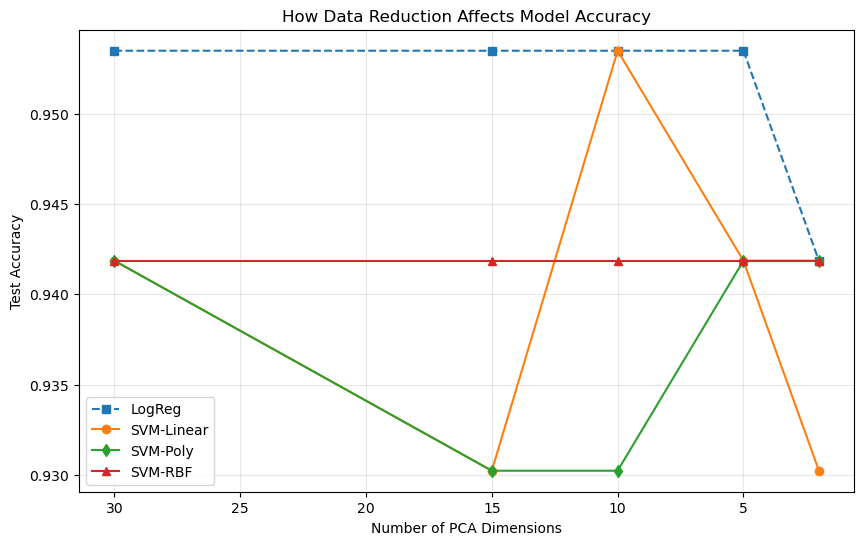

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Data loading using a relative path as requested
path_to_data = "breast_cancer_detection_data.csv"
raw_df = pd.read_csv(path_to_data)
phantom_cols = [c for c in raw_df.columns if 'Unnamed' in c]
raw_df = raw_df.drop(columns=['id'] + phantom_cols, errors='ignore')
# Pre-processing: Dropping ID and mapping diagnosis to numbers
# 'M' (Malignant) as 1, 'B' (Benign) as 0
#raw_df = raw_df.drop(columns=['id'])
raw_df['diagnosis'] = raw_df['diagnosis'].map({'M': 1, 'B': 0})
raw_df = raw_df.dropna()
# Separating features from the target label
full_features = raw_df.drop(columns=['diagnosis']).values
full_labels = raw_df['diagnosis'].values

feature_std = np.std(full_features, axis=0)
full_features = full_features[:, feature_std > 0]

X_normalized = (full_features - np.mean(full_features, axis=0)) / (np.std(full_features, axis=0) + 1e-8)
# Function to manually split data into 70:15:15
def partition_data(X, y, seed=42):
    """
    Splits the data into training, validation, and testing sets.
    - X, y: Features and Labels
    - seed: For reproducibility
    - Returns: Split sets (train, val, test)
    """
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    
    train_end = int(0.7 * len(X))
    val_end = int(0.85 * len(X))
    
    idx_train = indices[:train_end]
    idx_val = indices[train_end:val_end]
    idx_test = indices[val_end:]
    
    return X[idx_train], X[idx_val], X[idx_test], y[idx_train], y[idx_val], y[idx_test]

# Defining the dimensions we want to experiment with
dim_options = [30, 15, 10, 5, 2] # 30 is the original full-dimensional data
score_tracker = {"LR": [], "SVM_Linear": [], "SVM_Poly": [], "SVM_RBF": []}

#X_normalized = (full_features - np.mean(full_features, axis=0)) / (np.std(full_features, axis=0) + 1e-8)
print(f"{'Reduction':<20} | {'Dim %':<10} | {'Model':<10} | {'Test Accuracy'}")
print("-" * 60)

for d in dim_options:
    # Applying PCA if we are reducing dimensions
    if d < 30:
        compressor = PCA(n_components=d)
        X_transformed = compressor.fit_transform(X_normalized)
    else:
        X_transformed = X_normalized
        
    # Calculating the percentage reduction for the report
    pct_cut = ((30 - d) / 30) * 100
    
    # Splitting the (potentially reduced) data
    xtr, xvl, xte, ytr, yvl, yte = partition_data(X_transformed, full_labels)
    
    # MODEL 1: Logistic Regression ---
    model_lr = LogisticRegression(step_size=0.1, num_epochs=500)
    model_lr.fit(xtr, ytr)
    pred_lr = model_lr.predict(xte)
    acc_lr = np.mean(pred_lr == yte)
    score_tracker["LR"].append(acc_lr)
    print(f"30D -> {d:<2}D | {pct_cut:>5.1f}% | LR | {acc_lr:.4f}")

    # MODEL 2: SVM with Linear Kernel ---
    model_svml = SMO_SVM(core_type='linear', hardness=1.0,limit=20)
    model_svml.fit(xtr, ytr)
    pred_svml = model_svml.predict(xte)
    acc_svml = np.mean(pred_svml == yte)
    score_tracker["SVM_Linear"].append(acc_svml)
    print(f"30D -> {d:<2}D | {pct_cut:>5.1f}% | SVM-Lin | {acc_svml:.4f}")
    
    # MODEL 3: SVM with Polynomial Kernel ---
    # Adding degree=3 and coef0=1 as standard hyperparams
    model_svmp = SMO_SVM(core_type='poly', hardness=0.5, degree=2, slack=0.01, limit=5)
    model_svmp.fit(xtr, ytr)
    pred_svmp = model_svmp.predict(xte)
    acc_svmp = np.mean(pred_svmp == yte)
    score_tracker["SVM_Poly"].append(acc_svmp)
    print(f"30D -> {d:<2}D | {pct_cut:>5.1f}% | SVM-Poly | {acc_svmp:.4f}")

    # MODEL 4: SVM with RBF Kernel ---
    model_svmr = SMO_SVM(core_type='rbf', hardness=0.5, gamma=0.01,slack=0.01,limit=5)
    model_svmr.fit(xtr, ytr)
    pred_svmr = model_svmr.predict(xte)
    acc_svmr = np.mean(pred_svmr == yte)
    score_tracker["SVM_RBF"].append(acc_svmr)
    print(f"30D -> {d:<2}D | {pct_cut:>5.1f}% | SVM-RBF | {acc_svmr:.4f}")
    print("-" * 60)

# VISUALIZATION: Performance vs Dimensionality ---
plt.figure(figsize=(10, 6))
plt.plot(dim_options, score_tracker["LR"], marker='s', label='LogReg', linestyle='--')
plt.plot(dim_options, score_tracker["SVM_Linear"], marker='o', label='SVM-Linear')
plt.plot(dim_options, score_tracker["SVM_Poly"], marker='d', label='SVM-Poly')
plt.plot(dim_options, score_tracker["SVM_RBF"], marker='^', label='SVM-RBF')

plt.title("How Data Reduction Affects Model Accuracy")
plt.xlabel("Number of PCA Dimensions")
plt.ylabel("Test Accuracy")
plt.gca().invert_xaxis() 
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

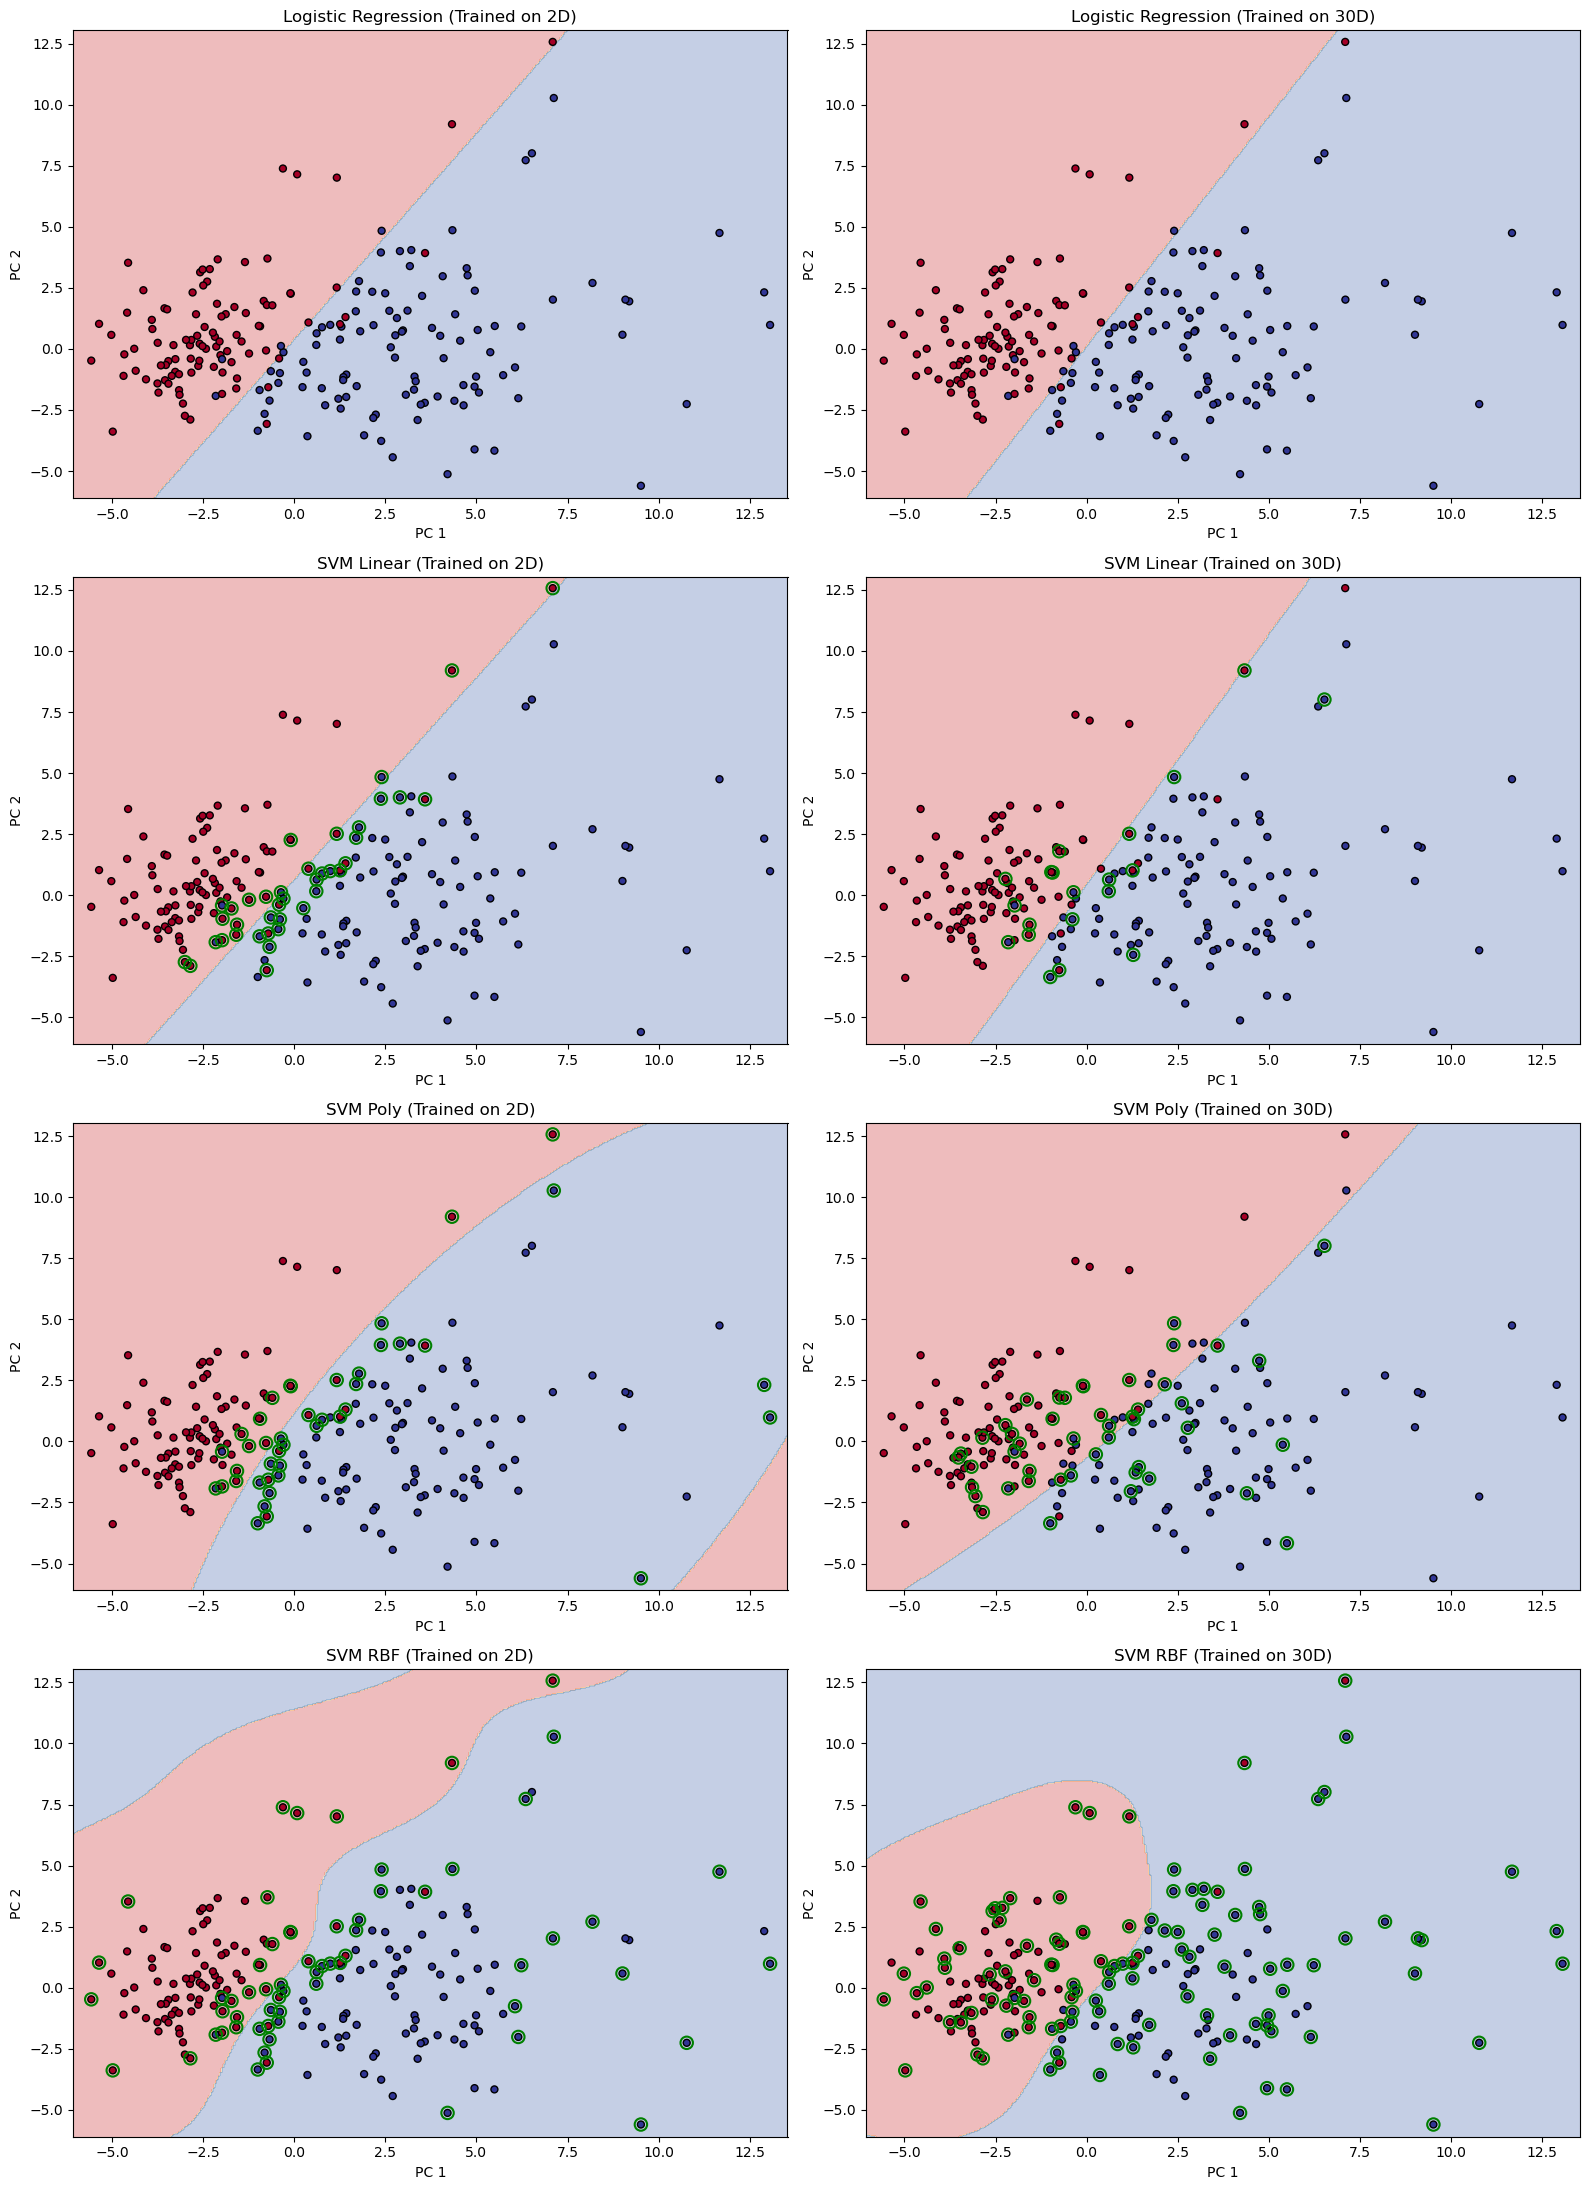

In [ ]:
# TASK 3: Decision Boundary Visualization ---

def plot_decision_landscape(model, X_space, y_truth, pca_obj=None, title_label="Model Map"):
    """
    Helper function to plot the decision regions for the classifier.
    """
    # Define the boundaries of our plot
    x_min, x_max = X_space[:, 0].min() - 0.5, X_space[:, 0].max() + 0.5
    y_min, y_max = X_space[:, 1].min() - 0.5, X_space[:, 1].max() + 0.5
    
    # Create a dense grid of points (mesh grid)
    step_gap = 0.05
    x_axis, y_axis = np.meshgrid(np.arange(x_min, x_max, step_gap),
                                 np.arange(y_min, y_max, step_gap))
    
    grid_points = np.c_[x_axis.ravel(), y_axis.ravel()]
    
    # If the model was trained on 30D, we map the 2D grid points back to 30D
    if pca_obj is not None:
        high_dim_grid = pca_obj.inverse_transform(grid_points)
        zone_predictions = model.predict(high_dim_grid)
    else:
        zone_predictions = model.predict(grid_points)
        
    zone_predictions = zone_predictions.reshape(x_axis.shape)
    
    # Plotting the colored regions
    plt.contourf(x_axis, y_axis, zone_predictions, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X_space[:, 0], X_space[:, 1], c=y_truth, edgecolors='k', s=25, cmap='RdYlBu')
    
    # Highlight support vectors if the model is an SVM
    if hasattr(model, 'support_pts') and model.support_pts is not None:
        sv_view = model.support_pts
        if sv_view.shape[1] > 2 and pca_obj is not None:
            sv_view = pca_obj.transform(sv_view)
        
        # Only plot if there are support vectors found
        if len(sv_view) > 0:
            plt.scatter(sv_view[:, 0], sv_view[:, 1], s=80, facecolors='none', 
                        edgecolors='green', label='Support Vectors', linewidth=1.5)

    plt.title(title_label)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")


# 1. Setup PCA and Data Subsets
# We use a 200-sample subset to ensure the SMO solver converges quickly
shrin_2d = PCA(n_components=2)
X_2d_viz = shrin_2d.fit_transform(X_normalized)[:200]
X_30d_viz = X_normalized[:200]
y_viz = full_labels[:200]

# 2. Define the Model list with configurations
plot_configs = [
    ("Logistic Regression", LogisticRegression(step_size=0.1, num_epochs=500)),
    ("SVM Linear", SMO_SVM(core_type='linear', hardness=1.0, limit=10)),
    ("SVM Poly", SMO_SVM(core_type='poly', hardness=1, degree=2, limit=10)),
    ("SVM RBF", SMO_SVM(core_type='rbf', hardness=1, gamma=0.1, limit=10))
]

# 3. Execution Loop for all 8 plots
fig = plt.figure(figsize=(16, 22))
plot_count = 1

for name, model_obj in plot_configs:
    # CASE 1: Model Trained on 2D Data ---
    plt.subplot(4, 2, plot_count)
    model_obj.fit(X_2d_viz, y_viz)
    plot_decision_landscape(model_obj, X_2d_viz, y_viz, 
                             title_label=f"{name} (Trained on 2D)")
    plot_count += 1
    
    # CASE 2: Model Trained on 30D Data ---
    plt.subplot(4, 2, plot_count)
    model_obj.fit(X_30d_viz, y_viz)
    # Using the PCA object to map the 30D boundary onto our 2D visualization
    plot_decision_landscape(model_obj, X_2d_viz, y_viz, 
                             pca_obj=shrin_2d, 
                             title_label=f"{name} (Trained on 30D)")
    plot_count += 1

plt.tight_layout()
plt.savefig('decision_boundaries_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### **Optional Question Bonus Instructions:**

The optional question (worth 2 marks) provides additional points that accumulate across all assignments. 

**How Optional Marks Work:**
- Optional marks accumulate across both assignments (each worth 15 marks, total 30 marks)
- Applied as bonus points to your total assignment score
- Final assignment component score is capped at 30 marks maximum
- Optional marks compensate for lost points in regular questions across assignments
- Provides a buffer to maintain high performance in the assignment component
